In [1]:
import dolfin
print("dolfin version:", dolfin.__version__)

dolfin version: 2019.1.0


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
from time import time
from itertools import product

from scipy.sparse import csr_matrix
from scipy.sparse import save_npz, load_npz

import os

from dolfin import *

In [3]:
from tqdm import tqdm  # pour les barres de progression dans les boucles

In [4]:
mesh_size = 200 
FE_type = "Lagrange"
degree = 2

mesh = UnitSquareMesh(mesh_size, mesh_size)
V = FunctionSpace(mesh, FE_type, degree)
print("Number of vertices:", mesh.num_vertices())

lines = {"mesh_size": mesh_size, "FE_type": FE_type, "degree": degree}
df_mesh_info = pd.DataFrame(lines, index=[0])

Number of vertices: 40401


In [5]:
# Boundary condition
class ConditionalBC(UserExpression):
    def eval(self, values, x):
        if x[0] < 0.1 and x[1] > 0.9:
            values[0] = 4.0
        elif x[1] < 0.1:
            values[0] = 1.0
        else:
            values[0] = 0.0
    def value_shape(self):
        return ()

u_D = ConditionalBC(degree=0)

def boundary(x, on_boundary):
    return on_boundary

bc = DirichletBC(V, u_D, boundary)

zero = Constant(0.0)
bc_zero = DirichletBC(V, zero, boundary)

# Define lifting
u_L = Function(V)
bc.apply(u_L.vector())  # fills u_L with the BC values

In [6]:
def heaviside(expr):
    return conditional(ge(expr, 0.0), 1.0, 0.0)

def get_conductivity(parameters):

    slope = parameters["slope"]; position = parameters["position"]; half_width = parameters["half_width"]; D_background = parameters["D_background"]; D_fracture = parameters["D_fracture"]
    x = SpatialCoordinate(mesh)
    x0 = x[0]
    x1 = x[1]

    norm_factor = Constant(100.0)


    arg1 = (position - half_width)/norm_factor - (slope/norm_factor * x0 + x1)
    arg2 = (slope/norm_factor * x0 + x1) - (position + half_width)/norm_factor
    arg3 = (slope/norm_factor * x0 + x1) - (position - half_width)/norm_factor
    arg4 = (position + half_width)/norm_factor - (slope/norm_factor * x0 + x1)

    K = D_background * (heaviside(arg1) + heaviside(arg2)) + D_fracture * heaviside(arg3) * heaviside(arg4)

    return K

In [7]:

def get_stiffness_and_load(parameters):
    K = get_conductivity(parameters)
    
    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(K*grad(u), grad(v))*dx
    L = Constant(0.0)*v*dx

    A = assemble(a)
    b = assemble(L)

    # Apply Dirichlet BCs to matrix and RHS vector
    b_mod = b.copy()
    A_uL = assemble(inner(K*grad(u_L), grad(v))*dx)
    b_mod.axpy(-1.0, A_uL)  # b_mod = b - A*u_L

    # Appliquer la BC homogène (u_0 = 0 sur bord)
    bc_zero.apply(A, b_mod)

    return A, b_mod

def PETSc_to_csr(A):
    """Convert a PETSc matrix to a SciPy CSR matrix."""

    # 1a) Grab the underlying PETSc Mat
    A_petsc = as_backend_type(A).mat()
    # 1b) Extract its CSR data (ai = row ptrs, aj = col inds, av = values)
    ai, aj, av = A_petsc.getValuesCSR()

    # 1c) Build a SciPy CSR matrix of the right shape
    n_rows, n_cols = A_petsc.getSize()
    A_csr = csr_matrix((av, aj, ai), shape=(n_rows, n_cols))

    return A_csr

def build_reduced_stiffness(A, V_r):
    A_csr = PETSc_to_csr(A)
    A_red = (V_r.T).dot(A_csr.dot(V_r))
    return A_red

def build_reduced_load(b, V_r):
    b_red = V_r.T.dot(b.get_local())
    return b_red

In [8]:
u_L_vect = np.array(u_L.vector().get_local())

In [9]:
u_L_vect.shape

(160801,)

In [10]:
example_parameters = {"slope": 40.0, "position": 70.0, "half_width": 5.0, "D_background": 100, "D_fracture": 1}
A_mu, b_mu = get_stiffness_and_load(example_parameters)
uh_HDM_sol = Function(V)
solve(A_mu, uh_HDM_sol.vector(), b_mu)
uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local()) + u_L_vect

In [11]:
uh_HDM_sol_vec.shape

(160801,)

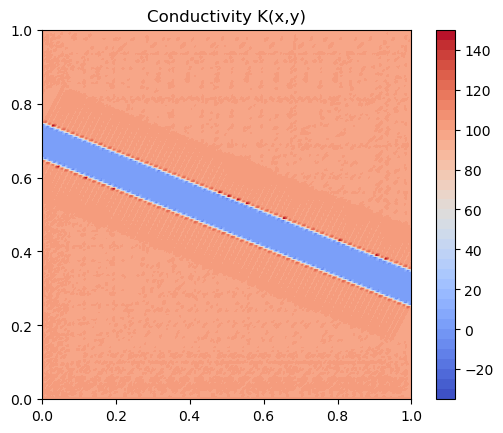

In [12]:
def plot_conductivity(parameters):
    K = get_conductivity(parameters)
    K_plot = project(K, V)

    p = plot(K_plot, cmap="coolwarm")
    plt.colorbar(p)
    plt.title("Conductivity K(x,y)")

K_test = get_conductivity(example_parameters)
plot_conductivity(example_parameters)

In [ ]:

def plot_boundary_condition(cmap='viridis'):
    dof_coords = V.tabulate_dof_coordinates()
    boundary_dofs = bc.get_boundary_values().keys()
    x_b = np.array([dof_coords[dof][0] for dof in boundary_dofs])
    y_b = np.array([dof_coords[dof][1] for dof in boundary_dofs])
    v_b = np.array([u_L.vector()[dof] for dof in boundary_dofs])

    sc = plt.scatter(x_b, y_b, c=v_b, cmap=cmap, 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.colorbar(sc, label='Valeur Condition Limite')

plt.title("Visualisation Discrète des Conditions aux Limites")

plot_boundary_condition()

In [ ]:
def plot_conductivity_boundary_condition(example_parameters):
    plot_conductivity(example_parameters)
    plot_boundary_condition() 
plot_conductivity_boundary_condition(example_parameters)

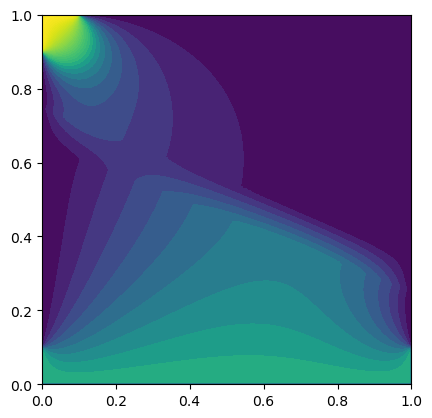

In [13]:

plot(uh_HDM_sol, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))

In [14]:
N_dof = V.dim()
Ns = 30
U_snapshot = np.zeros((N_dof, Ns))
print("dimension de U_snapshot:", U_snapshot.shape)

dimension de U_snapshot: (160801, 30)


In [ ]:
parameters_list = []
for i in tqdm(range(Ns), desc="Génération des Snapshots"):
    slope = np.random.uniform(20.0, 60.0)
    position = np.random.uniform(50.0, 90.0)
    half_width = np.random.uniform(3.0, 7.0)
    D_background = np.random.uniform(80.0, 120.0)
    D_fracture = np.random.uniform(0.5, 2.0)

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_list.append(parameters)

    A_mu, b_mu = get_stiffness_and_load(parameters)
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local())
    U_snapshot[:, i] = uh_HDM_sol_vec
print(parameters_list)

In [15]:
def numpy_to_fenics(numpy_vec, V, u_L_vect):
    """
    Reconstruit un objet Function FEniCS à partir d'un vecteur Numpy.
    """
    # 1. On crée une "boîte" FEniCS vide sur ton maillage V
    u_reconstruit = Function(V)
    
    # 2. On fait l'opération inverse mathématiquement (- au lieu de +)
    valeurs_internes = numpy_vec - u_L_vect
    
    # 3. On injecte le tableau numpy dans le vecteur FEniCS (l'inverse de get_local)
    u_reconstruit.vector().set_local(valeurs_internes)
    
    return u_reconstruit

In [ ]:
for i in range(9):
    vecteur_numpy = U_snapshot[:, i]    
    u_fenics = numpy_to_fenics(vecteur_numpy, V, u_L_vect)
    plt.subplot(3, 3, i + 1)
    p = plot(u_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.title(f"Snapshot n°{i+1}")
    plt.colorbar(p, fraction=0.046, pad=0.04) 
plt.tight_layout()
plt.show()

In [ ]:
U, S, Vt = np.linalg.svd(U_snapshot, full_matrices=False)



In [ ]:
print("number of singular values:", len(S))
print("U shape:", U.shape)
print("S shape:", S.shape)
print("Vt shape:", Vt.shape)
print("Singular values:", S)
plt.semilogy(S, marker='o')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

In [44]:
def plot_energy_contribution(S):
    energy = S**2
    cumulative_energy = np.cumsum(energy)
    total_energy = cumulative_energy[-1]
    energy_percentage = cumulative_energy / total_energy * 100
    print("Energy percentage:", energy_percentage)
    
    plt.figure(figsize=(8, 5))
    plt.plot(energy_percentage, marker='o')
    
    # --- LA CORRECTION EST ICI ---
    # On force l'axe Y à aller de 0 à 105% (ou 90 à 105% si tu préfères)
    plt.ylim(min(energy_percentage[0], 99), 100) 
    
    plt.xlabel('Number of Modes')
    plt.ylabel('Cumulative Energy (%)')
    plt.title('Cumulative Energy Contribution of Singular Values')
    plt.grid()
    plt.show()


In [ ]:
plot_energy_contribution(S)

## Un premier test

In [ ]:
test_parameters = {"slope": 45.0, "position": 75.0, "half_width": 5.0, "D_background": 100.0, "D_fracture": 1.0}
t = time()
A_test, b_test = get_stiffness_and_load(test_parameters)
V_r = U[:, :5]  # les 5 premiers modes
A_red = build_reduced_stiffness(A_test, V_r)
b_red = build_reduced_load(b_test, V_r)
u_red = np.linalg.solve(A_red, b_red)
u_approx = V_r.dot(u_red) + u_L_vect
u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
print("Time for ROM solve:", time() - t, "seconds")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
p1 = plot(u_approx_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.colorbar(p1)
plt.title("ROM Approximation (5 modes)")
plt.subplot(1, 2, 2)
t = time()
A_full, b_full = get_stiffness_and_load(test_parameters)
u_full = Function(V)
solve(A_full, u_full.vector(), b_full)
u_full_vec = np.array(u_full.vector().get_local()) + u_L_vect
u_full_fenics = numpy_to_fenics(u_full_vec, V, u_L_vect)
print("Time for full HDM solve:", time() - t, "seconds")
p2 = plot(u_full_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.colorbar(p2)
plt.title("Full HDM Solution")
plt.tight_layout()
plt.show()

## Qui est V1 ?

In [ ]:
print("les colones de U sont les modes POD, on les multiplie par 1000 pour mieux les visualiser")
for i in range(9):
    vecteur_numpy = U[:, i]*1000
    u_fenics = numpy_to_fenics(vecteur_numpy, V, u_L_vect)
    plt.subplot(3, 3, i + 1)
    p = plot(u_fenics)
    plt.title(f"V[{i+1}]")
    plt.colorbar(p, fraction=0.046, pad=0.04) 
plt.tight_layout()
plt.show()

In [16]:
def error_L2(u1, u2):
    """Calcule l'erreur relative L2 entre deux fonctions FEniCS."""
    diff = Function(V)
    diff.vector()[:] = u1.vector().get_local() - u2.vector().get_local()
    return norm(diff, 'L2') / norm(u1, 'L2')

In [ ]:
error = np.zeros(30)
for r in range(1, 31):
    V_r = U[:, :r]
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    error[r-1] = error_L2(u_full_fenics, u_approx_fenics)
    print(f"Error with {r} modes: {error[r-1]:.4e}")
plt.figure()
plt.semilogy(range(1, 31), error, marker='o')
plt.xlabel('Number of Modes (r)')
plt.ylabel('Relative L2 Error')
plt.title('Error vs Number of POD Modes')
plt.grid()
plt.show()

In [17]:
def normeA(u, A):
    """Calcule la norme induite par A de la fonction u (version 100% FEniCS)."""
    # 1. On crée un vecteur FEniCS vide de la même taille que u
    Au = Vector(u.vector()) 
    
    # 2. FEniCS fait la multiplication Matrice * Vecteur (Au = A * u)
    A.mult(u.vector(), Au)
    
    # 3. FEniCS fait le produit scalaire u^T * (Au)
    norme_A = np.sqrt(u.vector().inner(Au)) 
    
    return norme_A
def error_A_norm(u1, u2, A):
    """Calcule l'erreur relative dans la norme induite par A entre deux fonctions FEniCS."""
    diff = Function(V)
    diff.vector()[:] = u1.vector().get_local() - u2.vector().get_local()
    return normeA(diff, A) / normeA(u1, A)

In [ ]:

error_A = np.zeros(30)
for r in range(1, 31):
    V_r = U[:, :r]
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    error_A[r-1] = error_A_norm(u_full_fenics, u_approx_fenics, A_test)
    print(f"Error in A-norm with {r} modes: {error_A[r-1]:.4e}")


plt.figure()
plt.semilogy(range(1, 31), error_A, marker='o')
plt.xlabel('Number of Modes (r)')
plt.ylabel('Relative Error in A-norm')
plt.title('Error in A-norm vs Number of POD Modes')
plt.grid()
plt.show()

## CAS LINÉAIRE

Si on ne fait varier que $D_{\text{back}}$ et $D_{\text{fract}}$ dans la formule de $D_\mu(x, y)$ :

$D_\mu(x, y) = D_{\text{back}} \cdot \left( \sigma(-ax - y + (x_0 - w)) + \sigma(ax + y - (x_0 + w)) \right) + D_{\text{fract}} \cdot \sigma(-ax - y + (x_0 - w)) \cdot \sigma(ax + y - (x_0 + w))$

On se rend compte que la dépendance en les paramettre est linaire ainsi la matrice $A$ du probleme peut etre construit comme tel :

$\mathbf{A} = D_{\text{frac}} \cdot \mathbf{A}_{\text{frac}} + D_{\text{back}} \cdot \mathbf{A}_{\text{back}}$

Où $\mathbf{A}_{\text{frac}}$ et $\mathbf{A}_{\text{back}}$ ne sont calculées que une fois.


In [ ]:
Ns_lineaire = 50
U_snapshot_lineaire = np.zeros((N_dof, Ns_lineaire))
print("dimension de U_snapshot:", U_snapshot_lineaire.shape)

In [ ]:
parameters_list_lineaire = []
for i in tqdm(range(Ns_lineaire), desc="Génération des Snapshots"):
    slope = 40.0
    position = 70.0
    half_width = 5.0
    D_background = np.random.uniform(80.0, 120.0)
    D_fracture = np.random.uniform(0.5, 2.0)

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_list_lineaire.append(parameters)

    A_mu, b_mu = get_stiffness_and_load(parameters)
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local())
    U_snapshot_lineaire[:, i] = uh_HDM_sol_vec
print(parameters_list_lineaire)

In [ ]:
U_l, S_l, Vt_l = np.linalg.svd(U_snapshot_lineaire, full_matrices=False)

In [ ]:
print("number of singular values:", len(S_l))
print("U shape:", U_l.shape)
print("S shape:", S_l.shape)
print("Vt shape:", Vt_l.shape)
print("Singular values:", S_l)
plt.semilogy(S_l, marker='o', label='Singular Values (Linear Snapshots)')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

In [ ]:
plot_energy_contribution(S_l)

In [88]:
N_test = 10
parameters_test_lineaire_list = []
for i in range(N_test):
    slope = 40.0
    position = 70.0
    half_width = 5.0
    D_background = np.random.uniform(80.0, 120.0)
    D_fracture = np.random.uniform(0.5, 2.0)

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_test_lineaire_list.append(parameters)

In [ ]:
Ns_lineaire_range = [1, 3, 6, 9, 20, 50, 100]#range(1, Ns_lineaire+1, 10)
error_A_lineaire = np.zeros(len(Ns_lineaire_range))
time_linear = np.zeros(len(Ns_lineaire_range))


# ==========================================
# 0. TOUR DE CHAUFFE (WARM-UP)
# On force l'ordinateur à tout initialiser (FEniCS + NumPy) sur le plus gros cas pour preparer le cache et les compilations JIT, afin d'avoir des mesures de temps plus stables et représentatives lors du benchmark.
# ==========================================
print("Tour de chauffe en cours (compilation JIT et initialisation mémoire)...")
params_warmup = parameters_test_lineaire_list[0]
A_warmup, b_warmup = get_stiffness_and_load(params_warmup)
u_full_warmup = Function(V)
solve(A_warmup, u_full_warmup.vector(), b_warmup) # Chauffe FEniCS

r_max = Ns_lineaire_range[-1] # On prend le plus gros r (ex: 50)
V_r_warmup = U_l[:, :r_max]
A_red_warmup = build_reduced_stiffness(A_warmup, V_r_warmup) # Chauffe la projection
b_red_warmup = build_reduced_load(b_warmup, V_r_warmup)
u_red_warmup = np.linalg.solve(A_red_warmup, b_red_warmup)   # Chauffe le solveur NumPy
_ = V_r_warmup.dot(u_red_warmup) + u_L_vect                  # Chauffe le produit matriciel
print("Tour de chauffe terminé ! Lancement du benchmark...")
# ==========================================
A_test_linear_list = []
b_test_linear_list = []
HF_sol_linear_list = []
for i, params in enumerate(parameters_test_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    A_test_linear_list.append(A_test)
    b_test_linear_list.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_linear_list.append(u_full)




for j, r in enumerate(tqdm(Ns_lineaire_range, desc="Testing ROM with linear snapshots")):
    for i, params in enumerate(parameters_test_lineaire_list):

        u_full = HF_sol_linear_list[i]
        V_r = U_l[:, :r]

        # ==========================================
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ==========================================
        t0 = time() 
        A_test, b_test = get_stiffness_and_load(params)
        A_red = build_reduced_stiffness(A_test, V_r)
        b_red = build_reduced_load(b_test, V_r)
        
        u_red = np.linalg.solve(A_red, b_red)
        u_approx = V_r.dot(u_red) + u_L_vect
        
        
        t1 = time() 
        # ==========================================
        # FIN DU CHRONO
        # ==========================================
        
        # 2. POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
        error_A_lineaire[j] += error_A_norm(u_full, u_approx_fenics, A_test)
        
        time_linear[j] += (t1 - t0)

    # Moyenne sur les N_test paramètres
    error_A_lineaire[j] /= len(parameters_test_lineaire_list) 
    time_linear[j] /= len(parameters_test_lineaire_list)
    
    print(f"Error in A-norm with {r} modes: {error_A_lineaire[j]:.4e} | Time: {time_linear[j]:.4e} s")


In [89]:
HF_compution_time = 0
for i, params in enumerate(parameters_test_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    u_full = Function(V)
    t = time()
    solve(A_test, u_full.vector(), b_test)
    HF_compution_time += time() - t
HF_compution_time /= N_test
print(f"Average time for HF computation: {HF_compution_time:.4f} seconds")


Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FF

In [ ]:

# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color=color)
ax1.semilogy(Ns_lineaire_range, error_A_lineaire, marker='o', color=color, label='Error in A-norm')
ax1.tick_params(axis='y', labelcolor=color)
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.semilogy(Ns_lineaire_range, time_linear, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()


In [ ]:
print("évolution de la solution approchée en fonction du nombre de modes POD :")
for r in range(3):
    V_r = U_l[:, :r+1]
    A_test = A_test_linear_list[0]  # On prend le premier cas de test pour la visualisation
    b_test = b_test_linear_list[0]  # On prend le premier cas de test pour la visualisation
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    
    plt.subplot(2, 2, r + 1)
    p = plot(u_approx_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.title(f"ROM with {r+1} modes")
    plt.colorbar(p, fraction=0.046, pad=0.04)
plt.subplot(2, 2, 4)
u_full = HF_sol_linear_list[0]  # Solution HDM de référence pour le même cas de test
p = plot(u_full, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("Full HDM Solution")
plt.colorbar(p, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Maintenant essayions de chercher $\mathbf{A}_{\text{frac}}$ et $\mathbf{A}_{\text{back}}$

In [ ]:
p_f = {"slope": 40.0, "position": 70.0, "half_width": 5.0, "D_background": 0, "D_fracture": 1.0}
p_b = {"slope": 40.0, "position": 70.0, "half_width": 5.0, "D_background": 1.0, "D_fracture": 0}
A_frac, b_frac = get_stiffness_and_load(p_f)
A_back, b_back = get_stiffness_and_load(p_b)

In [ ]:
error_A_lineaire_sep = np.zeros(len(Ns_lineaire_range))
time_linear_sep = np.zeros(len(Ns_lineaire_range))


# ==========================================
# 0. TOUR DE CHAUFFE (WARM-UP)
# On force l'ordinateur à tout initialiser (FEniCS + NumPy) sur le plus gros cas pour preparer le cache et les compilations JIT, afin d'avoir des mesures de temps plus stables et représentatives lors du benchmark.
# ==========================================
print("Tour de chauffe en cours (compilation JIT et initialisation mémoire)...")
params_warmup = parameters_test_lineaire_list[0]
A_warmup, b_warmup = get_stiffness_and_load(params_warmup)
u_full_warmup = Function(V)
solve(A_warmup, u_full_warmup.vector(), b_warmup) # Chauffe FEniCS

r_max = Ns_lineaire_range[-1] # On prend le plus gros r (ex: 50)
V_r_warmup = U_l[:, :r_max]
A_frac_red_warmup = build_reduced_stiffness(A_frac, V_r_warmup) # Chauffe la projection
b_frac_red_warmup = build_reduced_load(b_frac, V_r_warmup)
A_back_red_warmup = build_reduced_stiffness(A_back, V_r_warmup)
b_back_red_warmup = build_reduced_load(b_back, V_r_warmup)
A_red_warmup = p_b["D_background"] * A_back_red_warmup + p_f["D_fracture"] * A_frac_red_warmup
b_red_warmup = p_b["D_background"] * b_back_red_warmup + p_f["D_fracture"] * b_frac_red_warmup
u_red_warmup = np.linalg.solve(A_red_warmup, b_red_warmup)   # Chauffe le solveur NumPy
_ = V_r_warmup.dot(u_red_warmup) + u_L_vect                  # Chauffe le produit matriciel
print("Tour de chauffe terminé ! Lancement du benchmark...")
# ==========================================
A_test_linear_list = []
b_test_linear_list = []
HF_sol_linear_list = []
for i, params in enumerate(parameters_test_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    A_test_linear_list.append(A_test)
    b_test_linear_list.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_linear_list.append(u_full)




for j, r in enumerate(tqdm(Ns_lineaire_range, desc="Testing ROM with linear snapshots")):
    for i, params in enumerate(parameters_test_lineaire_list):
        A_test = A_test_linear_list[i]#pour la norme A
        u_full = HF_sol_linear_list[i]
        V_r = U_l[:, :r]
        A_frac_red = build_reduced_stiffness(A_frac, V_r)
        b_frac_red = build_reduced_load(b_frac, V_r)
        A_back_red = build_reduced_stiffness(A_back, V_r)
        b_back_red = build_reduced_load(b_back, V_r)
        # ==========================================
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ==========================================
        t0 = time() 

        A_red = params["D_background"] * A_back_red + params["D_fracture"] * A_frac_red
        b_red = params["D_background"] * b_back_red + params["D_fracture"] * b_frac_red
        
        u_red = np.linalg.solve(A_red, b_red)
        u_approx = V_r.dot(u_red) + u_L_vect
        
        t1 = time() 
        # ==========================================
        # FIN DU CHRONO
        # ==========================================
        
        # 2. POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
        error_A_lineaire_sep[j] += error_A_norm(u_full, u_approx_fenics, A_test)
        
        time_linear_sep[j] += (t1 - t0)

    # Moyenne sur les N_test paramètres
    error_A_lineaire_sep[j] /= len(parameters_test_lineaire_list) 
    time_linear_sep[j] /= len(parameters_test_lineaire_list)
    
    print(f"Error in A-norm with {r} modes: {error_A_lineaire_sep[j]:.4e} | Time: {time_linear_sep[j]:.4e} s")

In [ ]:
# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color=color)
ax1.semilogy(Ns_lineaire_range, error_A_lineaire_sep, marker='o', color=color, label='Error in A-norm')
ax1.tick_params(axis='y', labelcolor=color)
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.semilogy(Ns_lineaire_range, time_linear_sep, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 7))

# --- AXE GAUCHE : ERREURS ---
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color='tab:red')

# Erreur "Standard"
ax1.semilogy(Ns_lineaire_range, error_A_lineaire, 
             marker='o', color='tab:red', linestyle='-', alpha=0.8, label='Error (Standard)')
# Erreur "Séparée" (_sep)
ax1.semilogy(Ns_lineaire_range, error_A_lineaire_sep, 
             marker='s', color='tab:orange', linestyle='--', alpha=0.8, label='Error (Séparée)')

ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.grid(True, which="both", ls="-", alpha=0.15)

# --- AXE DROITE : TEMPS ---
ax2 = ax1.twinx()
ax2.set_ylabel('Time (seconds)', color='tab:blue')

# Temps ROM "Standard"
ax2.semilogy(Ns_lineaire_range, time_linear, 
             marker='o', color='tab:blue', linestyle='-', alpha=0.8, label='Time ROM (Standard)')
# Temps ROM "Séparé" (_sep)
ax2.semilogy(Ns_lineaire_range, time_linear_sep, 
             marker='s', color='tab:cyan', linestyle='--', alpha=0.8, label='Time ROM (Séparée)')

# Temps Haute Fidélité (Référence horizontale)
ax2.axhline(y=HF_compution_time, color='navy', linestyle=':', linewidth=2, label='HF Time (Ref)')

ax2.tick_params(axis='y', labelcolor='tab:blue')

# --- LÉGENDE ET FINITIONS ---
fig.tight_layout()
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# On place la légende à l'endroit le plus vide (souvent center right ou upper right)
ax2.legend(lines1 + lines2, labels1 + labels2, loc='best', frameon=True, shadow=True)

plt.title('Comparison: Standard vs Separated POD\nError (A-norm) and Computation Time')
plt.show()

## CAS NON-LINÉAIRE

Maintenant faisons varier $a$, $w$ et $x_0$ plutot que $D_{\text{back}}$ et $D_{\text{fract}}$ dans la formule de $D_\mu(x, y)$ :

$D_\mu(x, y) = D_{\text{back}} \cdot \left( \sigma(-ax - y + (x_0 - w)) + \sigma(ax + y - (x_0 + w)) \right) + D_{\text{fract}} \cdot \sigma(-ax - y + (x_0 - w)) \cdot \sigma(ax + y - (x_0 + w))$

Cette fois-ci la dépendance n'est absolument pas lineaire.


In [30]:
Ns_non_lineaire = 200
U_snapshot_non_lineaire = np.zeros((N_dof, Ns_non_lineaire))
print("dimension de U_snapshot:", U_snapshot_non_lineaire.shape)

dimension de U_snapshot: (160801, 200)


In [34]:
parameters_list_non_lineaire = []
for i in tqdm(range(Ns_non_lineaire), desc="Génération des Snapshots"):
    slope = np.random.uniform(20.0, 60.0)
    position = np.random.uniform(50.0, 90.0)
    half_width = np.random.uniform(3.0, 7.0)
    D_background = 100.0
    D_fracture = 1.0

    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_list_non_lineaire.append(parameters)

Génération des Snapshots: 100%|██████████| 200/200 [00:00<00:00, 97000.56it/s]


In [ ]:
for i in tqdm(range(Ns_non_lineaire), desc="Génération des Snapshots"):


    A_mu, b_mu = get_stiffness_and_load(parameters_list_non_lineaire[i])
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local())
    U_snapshot_non_lineaire[:, i] = uh_HDM_sol_vec
print(parameters_list_non_lineaire)

Génération des Snapshots:   0%|          | 0/200 [00:00<?, ?it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   0%|          | 1/200 [00:05<19:50,  5.98s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:   1%|          | 2/200 [00:11<18:51,  5.71s/it]

...

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:  15%|█▌        | 30/200 [02:39<15:27,  5.46s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Génération des Snapshots:  15%|█▌        | 30/200 [02:45<15:36,  5.51s/it]


KeyboardInterrupt: 

In [ ]:
U_nl, S_nl, Vt_nl = np.linalg.svd(U_snapshot_non_lineaire, full_matrices=False)

In [ ]:
print(U_nl.shape)

In [ ]:
print("number of singular values:", len(S_nl))
print("U shape:", U_nl.shape)
print("S shape:", S_nl.shape)
print("Vt shape:", Vt_nl.shape)
print("Singular values:", S_nl)
plt.semilogy(S_nl, marker='o', label='Singular Values (Linear Snapshots)')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

In [ ]:
plot_energy_contribution(S_nl)

In [50]:
N_test = 10
parameters_test_non_lineaire_list = []
for i in range(N_test):
    slope = np.random.uniform(20.0, 60.0)
    position = np.random.uniform(50.0, 90.0)
    half_width = np.random.uniform(3.0, 7.0)
    D_background = 100.0
    D_fracture = 1.0
    parameters = {"slope": slope, "position": position, "half_width": half_width, "D_background": D_background, "D_fracture": D_fracture}
    parameters_test_non_lineaire_list.append(parameters)

In [ ]:
Ns_non_lineaire_range = range(0, Ns_non_lineaire+1, 10)
error_A_non_lineaire = np.zeros(len(Ns_non_lineaire_range))
error_L2_non_lineaire = np.zeros(len(Ns_non_lineaire_range))
time_non_linear = np.zeros(len(Ns_non_lineaire_range))


# ==========================================
# 0. TOUR DE CHAUFFE (WARM-UP)
# On force l'ordinateur à tout initialiser (FEniCS + NumPy) sur le plus gros cas pour preparer le cache et les compilations JIT, afin d'avoir des mesures de temps plus stables et représentatives lors du benchmark.
# ==========================================
print("Tour de chauffe en cours (compilation JIT et initialisation mémoire)...")
params_warmup = parameters_test_non_lineaire_list[0]
A_warmup, b_warmup = get_stiffness_and_load(params_warmup)
u_full_warmup = Function(V)
solve(A_warmup, u_full_warmup.vector(), b_warmup) # Chauffe FEniCS

r_max = Ns_non_lineaire_range[-1] # On prend le plus gros r (ex: 50)
V_r_warmup = U_nl[:, :r_max]
A_red_warmup = build_reduced_stiffness(A_warmup, V_r_warmup) # Chauffe la projection
b_red_warmup = build_reduced_load(b_warmup, V_r_warmup)
u_red_warmup = np.linalg.solve(A_red_warmup, b_red_warmup)   # Chauffe le solveur NumPy
_ = V_r_warmup.dot(u_red_warmup) + u_L_vect                  # Chauffe le produit matriciel
print("Tour de chauffe terminé ! Lancement du benchmark...")
# ==========================================
A_test_list = []
b_test_list = []
HF_sol_list = []
for i, params in enumerate(parameters_test_non_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    A_test_list.append(A_test)
    b_test_list.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_list.append(u_full)




for j, r in enumerate(tqdm(Ns_non_lineaire_range, desc="Testing ROM with non-linear snapshots")):
    for i, params in enumerate(parameters_test_non_lineaire_list):
        A_test = A_test_list[i]
        b_test = b_test_list[i]
        u_full = HF_sol_list[i]
        # ==========================================
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ==========================================
        t0 = time() 

        V_r = U_nl[:, :r]
        A_red = build_reduced_stiffness(A_test, V_r)
        b_red = build_reduced_load(b_test, V_r)
        
        u_red = np.linalg.solve(A_red, b_red)
        u_approx = V_r.dot(u_red) + u_L_vect
        
        t1 = time() 
        # ==========================================
        # FIN DU CHRONO
        # ==========================================
        
        # 2. POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
        error_A_non_lineaire[j] += error_A_norm(u_full, u_approx_fenics, A_test)
        error_L2_non_lineaire[j] += error_L2(u_full, u_approx_fenics)
        time_non_linear[j] += (t1 - t0)

    # Moyenne sur les N_test paramètres
    error_A_non_lineaire[j] /= len(parameters_test_non_lineaire_list) 
    error_L2_non_lineaire[j] /= len(parameters_test_non_lineaire_list)
    time_non_linear[j] /= len(parameters_test_non_lineaire_list)
    
    print(f"Error in A-norm with {r} modes: {error_A_non_lineaire[j]:.4e} | Error in L2-norm: {error_L2_non_lineaire[j]:.4e}     | Time: {time_non_linear[j]:.4e} s")

Tour de chauffe en cours (compilation JIT et initialisation mémoire)...


NameError: name 'U_nl' is not defined

In [ ]:
HF_compution_time_nl = 0
for i, params in enumerate(parameters_test_non_lineaire_list):
    A_test, b_test = get_stiffness_and_load(params)
    u_full = Function(V)
    t = time()
    solve(A_test, u_full.vector(), b_test)
    HF_compution_time_nl += time() - t
HF_compution_time_nl /= N_test
print(f"Average time for HF computation: {HF_compution_time_nl:.4f} seconds")

In [ ]:

# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color=color)
ax1.semilogy(Ns_non_lineaire_range, error_A_non_lineaire, marker='o', color=color, label='Error in A-norm')
ax1.tick_params(axis='y', labelcolor=color)
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.plot(Ns_non_lineaire_range, time_non_linear, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()

In [ ]:
# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in L2-norm', color=color)

# Plotter l'erreur en norme L2 sur l'axe principal (gauche)
color = 'tab:orange'
ax1.semilogy(Ns_non_lineaire_range, error_L2_non_lineaire, marker='s', color=color, linestyle='--', label='Error in L2-norm')
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.plot(Ns_non_lineaire_range, time_non_linear, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()

In [ ]:
# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color=color)
ax1.semilogy(Ns_non_lineaire_range, error_A_non_lineaire, marker='o', color=color, label='Error in A-norm')
ax1.tick_params(axis='y', labelcolor=color)
# Plotter l'erreur en norme L2 sur l'axe principal (gauche)
color = 'tab:orange'
ax1.semilogy(Ns_non_lineaire_range, error_L2_non_lineaire, marker='s', color=color, linestyle='--', label='Error in L2-norm')
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.plot(Ns_non_lineaire_range, time_non_linear, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()

In [ ]:
print("évolution de la solution approchée en fonction du nombre de modes POD :")
for i, r in enumerate(range(1, 31, 10)):
    V_r = U_nl[:, :r]
    A_test = A_test_list[0]  # On prend le premier cas de test pour la visualisation
    b_test = b_test_list[0]  # On prend le premier cas de test pour la visualisation
    A_red = build_reduced_stiffness(A_test, V_r)
    b_red = build_reduced_load(b_test, V_r)
    u_red = np.linalg.solve(A_red, b_red)
    u_approx = V_r.dot(u_red) + u_L_vect
    u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
    
    plt.subplot(2, 2, i + 1)
    p = plot(u_approx_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.title(f"ROM with {r} modes")
    plt.colorbar(p, fraction=0.046, pad=0.04)
plt.subplot(2, 2, 4)
u_full = HF_sol_list[0]  # Solution HDM de référence pour le même cas de test
p = plot(u_full, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("Full HDM Solution")
plt.colorbar(p, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## L'EIM
Nous sommes donnés une fonction $g(·;µ) \in L∞(Ω)$ de régularité suffisante. 

Pour commencer, nous choisissons $\mu_g^1$, et définissons $S_g^1 = \{\mu_g^1\}$, $\xi_1 ≡ g(x;\mu_g^1)$, et $W_g^1 = \text{span}\{\xi_1\}$ ; nous supposons que $\xi_1 ≠ 0$. 

Ensuite, pour $M ≥ 2$, nous définissons $\mu_g^M = \arg \max_{\mu \in \Xi_g} \inf_{z \in W_g^{M-1}} \|g(·;\mu)− z\|_{L∞(Ω)}$, où $\Xi_g$ est un échantillon de paramètre suffisamment fin sur $D$. 

Nous définissons ensuite $S_g^M = S_g^{M-1} ∪ \mu_g^M$, $\xi_M = g(x;\mu_g^M)$, et $W_g^M = \text{span}\{\xi_m, 1 ≤ m ≤ M\}$ . 

Notez que, grâce à notre approximation de vérité, $\mu_g^M$ est la solution d'un programme linéaire standard.



In [18]:
def g(mu):
    """
    Accepte mu sous forme de dictionnaire ou de liste/array.
    """
    if isinstance(mu, dict):
        # Si c'est déjà un dictionnaire, on l'utilise tel quel
        parameters = mu
    else:
        # Si c'est une liste, on la convertit
        parameters = {
            "slope": mu[0], 
            "position": mu[1], 
            "half_width": mu[2], 
            "D_background": mu[3], 
            "D_fracture": mu[4]
        }
        
    K = get_conductivity(parameters)
    return project(K, V)


M_max = 40

MU_MIN = [
    20.0,
    50.0,
    3.0
]

# --- BORNES SUPÉRIEURES (MAX) ---
MU_MAX = [
    60.0,
    90.0,
    7.0
]



In [19]:


# Générer des points aléatoires
RandomPoints = np.random.rand(400, 3) * (np.array(MU_MAX) - np.array(MU_MIN)) + np.array(MU_MIN)

# Transformer les points en une liste de listes exploitables par vos fonctions
D_train = [
    [s, p, hw, 100.0, 1.0]
    for s, p, hw in RandomPoints
]

print(f"Taille de l'espace d'entraînement D_train : {len(D_train)} points")


Taille de l'espace d'entraînement D_train : 400 points


In [20]:
from joblib import Parallel, delayed

def compute_single_snapshot(mu):
    # On appelle ta fonction g(mu)
    # L'avantage du threading est qu'il accède directement à 'V' et 'g' sans copie
    G = g(mu)
    return G.vector().get_local()

# --- CONFIGURATION ---
N_train = len(D_train)
print(f"Création de la Matrice : {N_train} paramètres.")

# Lancement avec le backend 'threading' pour éviter l'erreur de Pickle
results = Parallel(n_jobs=-1, prefer="threads")(
    delayed(compute_single_snapshot)(mu) for mu in tqdm(D_train, desc="Phase Offline Parallèle")
)

Snapshots_conductivite = np.array(results)
print(f"\nTerminé ! Forme de la matrice : {Snapshots_conductivite.shape}")

Création de la Matrice : 400 paramètres.


Phase Offline Parallèle:   0%|          | 0/400 [00:00<?, ?it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Phase Offline Parallèle:   6%|▌         | 22/400 [00:06<01:46,  3.55it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.



KeyboardInterrupt



ensuite :
$\mu_g^M = \arg \max_{\mu \in \Xi_g} \inf_{z \in W_g^{M-1}} \|g(·;\mu)− z\|_{L∞(Ω)}$


In [ ]:
U_EIM, S_EIM, Vt_EIM = np.linalg.svd(Snapshots_conductivite, full_matrices=False)

In [ ]:
plt.semilogy(S_EIM, marker='o', label='Singular Values (Conductivity Snapshots)')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Conductivity Snapshot Matrix')
plt.grid()
plt.show()

In [ ]:
# =======================================================
    # 1. ÉTAPE GREEDY : Recherche du pire paramètre
    # =======================================================
    if m == 0:
        # Initialisation : on prend le max absolu parmi tous les snapshots
        norms = np.max(np.abs(Snapshots_conductivite), axis=1)
        best_idx = np.argmax(norms)
        err_max = norms[best_idx]
    else:
        err_max = -1.0
        best_idx = -1
        
        # On utilise notre belle matrice B pré-calculée
        B_current = B_complet[:m, :m]
        T_current = Magic_Points[:m]
        
        for i in range(N_train):
            g_test = Snapshots_conductivite[i]
            
            # --- C'est ici que se fait la "projection" instantanée ! ---
            g_magic = g_test[T_current]
            beta = np.linalg.solve(B_current, g_magic)
            g_interp = beta @ Q[:m, :]
            
            # Calcul de l'erreur L-infini
            err = np.max(np.abs(g_test - g_interp))
            # -----------------------------------------------------------
            
            if err > err_max:
                err_max = err
                best_idx = i


In [ ]:
# --- INITIALISATION ---
M_max = 400  # Nombre de modes EIM souhaités
N_train = len(D_train)
nb_dofs = V.dim()

Q = np.zeros((M_max, nb_dofs))     # Base de fonctions q_m (normalisées)
Magic_Points = []                  # Ensemble des t_m (les indices)
S_mu = []                          # Paramètres sélectionnés

# Ps on remarque que les coeffs de l'articles B_ij^M sont indépendant de M donc on peut faire que une matrice 
B_complet = np.zeros((M_max, M_max))
print("Lancement de l'algorithme DEIM (SVD + Magic Points)...")

for m in tqdm(range(M_max), desc="Construction de la base DEIM"):
    
    # =======================================================
    # 1. SÉLECTION DU MODE (Fini le Greedy, merci la SVD !)
    # =======================================================
    # Le m-ième mode spatial dominant est simplement la m-ième ligne de Vt_EIM
    xi_M = Vt_EIM[m, :]

    # =======================================================
    # 2. CONSTRUCTION DU NOUVEAU MODE EIM/DEIM
    # =======================================================

        # Modes suivants
    T_current = Magic_Points[:m]
        
        # Résolution pour trouver le résidu
    xi_magic = xi_M[T_current]
    sigma = np.linalg.solve(B_complet[:m, :m], xi_magic)
        
        # Le fameux résidu r_M
    r_M = xi_M - (sigma @ Q[:m, :])
        
        # Le nouveau Magic Point t_M
    t_M = np.argmax(np.abs(r_M))
    Magic_Points.append(t_M)
        
        # La nouvelle base q_M normalisée
    q_M = r_M / r_M[t_M]
    Q[m, :] = q_M
        
        # Mise à jour de la matrice B
    for i in range(m + 1):
        for j in range(m + 1):
                B_complet[i, j] = Q[j, Magic_Points[i]]


print("\nBase DEIM générée avec succès !")

In [ ]:
# 1. Norme inf ultra-rapide (Que du NumPy !)
#def norm_inf_numpy(G_array, z_array):
    return np.max(np.abs(G_array - z_array))


# On supprime totalement descente_numpy !

#def projection_numpy(G_array, W, n, magic_points):
    """
    Projection EIM pure : on résout le système linéaire exact aux Magic Points.
    """
    if n == 0:
        return np.zeros(W.shape[1])
        
    # 1. On extrait les n premiers Magic Points
    mp_actifs = magic_points[:n]
    
    # 2. On extrait la valeur du snapshot uniquement sur ces points (Vecteur G de taille n)
    G_magic = G_array[mp_actifs]
    
    # 3. On construit la matrice d'interpolation B (taille n x n)
    # B correspond aux valeurs de nos modes de base évalués aux Magic Points
    W_active = W[:n]
    # On transpose pour avoir une matrice où i = point magique, j = mode
    B = W_active[:, mp_actifs].T
    
    # 4. Résolution du petit système linéaire (Instantané !)
    z = np.linalg.solve(B, G_magic)
    
    # 5. On reconstruit le vecteur complet sur tout le maillage
    return z @ W_active

# 4. La boucle principale optimisée
#def recherche_mu_max_discret(W, n, D_train, magic_points):
    print(f"Recherche du mu_max dans D_train avec n={n} modes...")
    err_max = -1.0
    mu_max = None
    total_mu = len(D_train)
    
    for i, mu_test in enumerate(D_train):
        # ---------------------------------------------------------
        # L'UNIQUE APPEL FENICS (C'est ici qu'on paie le prix du calcul)
        G = g(mu_test)
        G_array = G.vector().get_local()
        # ---------------------------------------------------------
        
        # Tout le reste est des maths Numpy, c'est instantané
        z_array = projection_numpy(G_array, W, n, magic_points)
        erreur_actuelle = norm_inf_numpy(G_array, z_array)
        
        if erreur_actuelle > err_max:
            err_max = erreur_actuelle
            mu_max = mu_test.copy()
            
        # Affichage plus fréquent pour que tu voies que ça ne freeze pas
        if (i + 1) % 5 == 0 or i == total_mu - 1:
            print(f"  -> Progression : {i+1}/{total_mu} (Max en cours : {err_max:.2e})", end="\r")
            
    print(f"\n  -> Recherche terminée ! Pire erreur : {err_max:.2e}")
    return mu_max, err_max

Nous construisons maintenant des ensembles imbriqués de points d'interpolation $ T_M = \{t_1, \ldots, t_M\} $, pour $ 1 \leq M \leq M_{\text{max}} $. 

Nous commençons par définir $ t_1 = \arg ess\sup_{x \in \Omega} |\xi_1(x)| $ (nomalement argessup mais une fois discretisé on s'en fou). $ q_1 = \frac{\xi_1(x)}{\xi_1(t_1)} $, et $ B_{1,1} = 1 $
Ensuite, pour $ M = 2, \ldots, M_{\text{max}} $, nous résolvons le système linéaire $ \sum_{j=1}^{M-1} \sigma_{M-1,j} q_j(t_i) = \xi_M(t_i), \quad 1 \leq i \leq M-1$ et définissons $ r_M(x) = \xi_M(x) - \sum_{j=1}^{M-1} \sigma_{M-1,j} q_j(x) $, $ t_M = \arg ess\sup_{x \in \Omega} |r_M(x)| $, $ q_M(x) = \frac{r_M(x)}{r_M(t_M)} $, et $ B_{i,j}^M = q_j(t_i) $, pour $ 1 \leq i, j \leq M $.


In [21]:
def numpy_to_fenics_param(q, V):
    """
    Convertit un vecteur NumPy en une fonction FEniCS dans l'espace V.
    """
    f = Function(V)
    f.vector()[:] = q
    return f

In [ ]:

plt.figure(figsize=(12, 8)) # Increase figure size to 15x10 inches

for j, i in enumerate([1, 10, 20, 50, 100,300]):
    plt.subplot(2, 3, j + 1)
    
    # Increase space between subplots by adjusting the subplot params

    mode_fenics = numpy_to_fenics_param(Q[i, :], V)
    p = plot(mode_fenics,
             cmap="coolwarm", 
             norm=colors.SymLogNorm(linthresh=1e-3, vmin=-1.0, vmax=1.5))
    plt.colorbar(p)
    plt.title(f"Mode EIM {i+1}")


In [ ]:
G_test = Snapshots_conductivite[0, :]  # On prend le premier snapshot de test comme conductivité de référence   
plt.figure(figsize=(12, 8))
for j, m in enumerate(tqdm([15, 50, 100, 200, 399], desc="Visualisation de l'approximation EIM")):
    q_m = Q[m-1, :]
    
    G = np.array([G_test[Magic_Points[k]] for k in range(m)])
    beta = np.linalg.solve(B_complet[:m, :m], G)
    g_f = beta @ Q[:m, :]
    g_f_fenics = numpy_to_fenics_param(g_f, V)
    plt.subplot(2, 3, j+1)
    p = plot(g_f_fenics,
             cmap="coolwarm", 
             norm=colors.SymLogNorm(linthresh=1e-3, vmin=0.0, vmax=200.0))
    plt.colorbar(p)
    plt.title(f"m={m}")

plt.subplot(2, 3, 6)
p = plot(numpy_to_fenics_param(G_test, V),
             cmap="coolwarm", 
             norm=colors.SymLogNorm(linthresh=1e-3, vmin=0.0, vmax=200.0))
plt.colorbar(p)
plt.title("HDM")

## maintenant sur une une conductivité qui n'est pas dans la snapshot

In [ ]:

G_param = parameters_test_non_lineaire_list[0]
erreur_conductivite = np.zeros(len([10, 40, 100, 200, 300]))
K_param = get_conductivity(G_param)
K_fenics = project(K_param, V)
K_vect = K_fenics.vector().get_local()
plt.figure(figsize=(12, 8))
for j, m in enumerate(tqdm([10, 40, 100, 200, 300], desc="Visualisation de l'approximation EIM pour un paramètre réel")):
    G = np.array([K_vect[Magic_Points[k]] for k in range(m)])
    beta = np.linalg.solve(B_complet[:m, :m], G)
    g_f = beta @ Q[:m, :]
    g_f_fenics = numpy_to_fenics_param(g_f, V)
    erreur_conductivite[j] = errornorm(K_fenics, g_f_fenics, 'L2')
    plt.subplot(2, 3, j + 1)

    p = plot(g_f_fenics,
             cmap="coolwarm", 
             norm=colors.SymLogNorm(linthresh=1e-3, vmin=0.0, vmax=200.0))
    plt.colorbar(p)
    plt.title(f"m={m}")

plt.subplot(2, 3, 6)

p = plot(K_fenics,
             cmap="coolwarm", 
             norm=colors.SymLogNorm(linthresh=1e-3, vmin=0.0, vmax=200.0))
plt.colorbar(p)
plt.title("HDM")


In [ ]:

plt.figure(figsize=(8, 5))
plt.semilogy([10, 40, 100, 200, 300], erreur_conductivite, marker='o', color='tab:green', linestyle='--')
plt.xlabel('Number of EIM Modes (m)')
plt.ylabel('L2 Error in Conductivity')
plt.title('Convergence of EIM Approximation (Conductivity)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

Finally, our coefficient function approximation is the interpolant of $g$ over $\mathcal{T}_M$ as defined from Lemma 2.3:

$$
g_M(x; \mu) = \sum_{m=1}^{M} \beta_m(\mu) q_m(x),
$$

where

$$
\sum_{j=1}^{M} B_{ij}^M \beta_j (\mu) = g(t_i; \mu), \quad 1 \leq i \leq M.
$$



In [22]:
def get_A_b_EIM(q):
    K = numpy_to_fenics_param(q, V)
    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(K*grad(u), grad(v))*dx
    L = Constant(0.0)*v*dx
    
    A = assemble(a)
    b = assemble(L)

    # Apply Dirichlet BCs to matrix and RHS vector
    b_mod = b.copy()
    A_uL = assemble(inner(K*grad(u_L), grad(v))*dx)
    b_mod.axpy(-1.0, A_uL)  # b_mod = b - A*u_L

    # Appliquer la BC homogène (u_0 = 0 sur bord)
    bc_zero.apply(A, b_mod)

    return A, b_mod

In [ ]:
Vt_EIM.shape


In [ ]:
U_nl.shape

In [ ]:
r_EIM = 20 # Par exemple (choisis le nombre de modes POD r que tu as fixé)
A_reduit_EIM_list = []
b_reduit_EIM_list = []
V_r = U_nl[:, :r_EIM]
print("Projection hors-ligne des modes EIM...")
for m in tqdm(range(300), desc="Calcul des A et b pour les modes EIM"):
    # On récupère le m-ième mode EIM
    q_m = Q[m, :]   

    
    # 1. On assemble les matrices Haute Fidélité pour ce mode EIM spécifique
    A_EIM, b_EIM = get_A_b_EIM(q_m)
    
    # 2. On les projette sur la base POD V_r (CORRECTION ICI)
    A_red_EIM = build_reduced_stiffness(A_EIM, V_r)
    b_red_EIM = build_reduced_load(b_EIM, V_r)
    
    # 3. On stocke dans la liste
    A_reduit_EIM_list.append(A_red_EIM)
    b_reduit_EIM_list.append(b_red_EIM)

print("Matrices réduites EIM générées avec succès !")


In [ ]:
_, b_zero_HF = get_A_b_EIM(np.zeros(V.dim()))
b_source_red = build_reduced_load(b_zero_HF, V_r)

In [155]:
M_EIM = range(1, 300, 15) 
error_L2_EIM = np.zeros(len(M_EIM))
time_EIM = np.zeros(len(M_EIM))

A_test_list = []
b_test_list = []
HF_sol_list = []
g_test_list = []

print("Pré-calcul des solutions HF et des champs de conductivité...")
for i, params in enumerate(tqdm(parameters_test_non_lineaire_list, desc="Pré-calcul FEniCS")):
    # On calcule la matrice et le second membre
    A_test, b_test = get_stiffness_and_load(params)
    A_test_list.append(A_test)
    b_test_list.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_list.append(u_full)
    
    # On paie le prix de FEniCS (project) UNE SEULE FOIS par paramètre
    G_array = g(params).vector().get_local()
    g_test_list.append(G_array)

Pré-calcul des solutions HF et des champs de conductivité...


Pré-calcul FEniCS:  10%|█         | 1/10 [00:05<00:47,  5.28s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Pré-calcul FEniCS:  20%|██        | 2/10 [00:26<01:56, 14.53s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


...

Pré-calcul FEniCS:  80%|████████  | 8/10 [01:23<00:19,  9.92s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Pré-calcul FEniCS:  90%|█████████ | 9/10 [01:34<00:10, 10.27s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Pré-calcul FEniCS: 100%|██████████| 10/10 [01:44<00:00, 10.49s/it]


In [ ]:
# On extrait les coordonnées géométriques de tous les degrés de liberté (1 seule fois)
dof_coords = V.tabulate_dof_coordinates()

def g_point(mu, point_idx):
    """
    Évalue la conductivité EXACTEMENT au noeud spatial point_idx.
    Temps d'exécution : ~0.0001s.
    """
    if isinstance(mu, dict):
        parameters = mu
    else:
        parameters = {
            "slope": mu[0], "position": mu[1], "half_width": mu[2], 
            "D_background": mu[3], "D_fracture": mu[4]
        }
    
    K = get_conductivity(parameters)
    coord = dof_coords[point_idx]
    
    try:
        # L'étoile (*) est magique : elle déballe le tableau [x, y] en arguments K(x, y)
        return K(*coord)
    except Exception:
        # Code de secours robuste qui attrape TOUTES les erreurs (ValueError, TypeError, etc.)
        val = np.zeros(1)
        K.eval(val, coord)
        return val[0]

In [ ]:
print("\nLancement du benchmark Online EIM...")


for j, m in enumerate(tqdm(M_EIM, desc="Testing ROM with EIM")):
    
    for i, params in enumerate(parameters_test_non_lineaire_list):

        # Récupération de la conductivité de test pré-calculée
        g_mu_complet = g_test_list[i]

        # ----------------------------------------------------
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ----------------------------------------------------
        t0 = time()
        
        # On extrait comme de vrais "capteurs" physiques sur les Magic Points
        G = np.array([g_mu_complet[Magic_Points[k]] for k in range(m)])
        
        # Calcul des coefficients EIM (B[m-1] car l'index commence à 0)
        beta = np.linalg.solve(B_complet[:m, :m], G) # orriginal 

        #beta = np.linalg.lstsq(B_complet[:m, :m], G, rcond=None)[0] # Solution plus stable numériquement
        
        # Assemblage réduit EIM (Combinaison linéaire pure NumPy)
        A_red_EIM = np.sum([beta[k] * A_reduit_EIM_list[k] for k in range(m)], axis=0)
        b_red_EIM = np.sum([beta[k] * b_reduit_EIM_list[k] for k in range(m)], axis=0)
        
        # Résolution du petit système réduit
        u_red_EIM = np.linalg.solve(A_red_EIM, b_red_EIM)
        
        # Reconstruction rapide NumPy
        u_approx_EIM = V_r.dot(u_red_EIM) + u_L_vect
        
        t1 = time()
        # ----------------------------------------------------
        # FIN DU CHRONO
        # ----------------------------------------------------
        
        # POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx_EIM, V, u_L_vect) 
        
        u_full = HF_sol_list[i]
        A_test = A_test_list[i]
        
        error_L2_EIM[j] += error_L2(u_full, u_approx_fenics)
        time_EIM[j] += (t1 - t0)

    # Moyennes
    error_L2_EIM[j] /= len(parameters_test_non_lineaire_list) 
    time_EIM[j] /= len(parameters_test_non_lineaire_list)
    


In [ ]:
from scipy import stats
# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in L2-norm', color=color)
ax1.semilogy(M_EIM, error_L2_EIM, marker='o', color=color, label='Error in L2-norm')
ax1.tick_params(axis='y', labelcolor=color)

# Calculer la régression linéaire en échelle logarithmique
slope, intercept, r_value, p_value, std_err = stats.linregress(M_EIM, error_L2_EIM)
linear_fit = slope * M_EIM + intercept

# Plotter l'approximation linéaire de l'erreur en pointillé rouge
ax1.semilogy(M_EIM, linear_fit, 'r--', label='Linear Fit of Error')

# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()

# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.semilogy(M_EIM, time_EIM, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)

# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Ajouter un titre
plt.title('Average Error in L2-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')

# Afficher le graphique
plt.show()

In [ ]:

# Créer la figure
fig, ax1 = plt.subplots(figsize=(12, 8))

# =========================================================
# AXE Y GAUCHE : ERREURS (Norme A)
# =========================================================

# 1. Erreur POD pure (Bas / Gauche)
color_err_pod = 'tab:red'
ax1.set_xlabel('Number of POD Modes (r)', color=color_err_pod, fontweight='bold')
ax1.set_ylabel('Average Relative Error in L2-norm', color='black')
l1, = ax1.semilogy(Ns_non_lineaire_range, error_L2_non_lineaire, marker='o', 
                   color=color_err_pod, label='Error POD (r)')
ax1.tick_params(axis='x', labelcolor=color_err_pod)

# 2. Erreur EIM (Haut / Gauche) -> Partage l'axe Y gauche (ax1.twiny)
ax3 = ax1.twiny()
color_err_eim = 'darkorange'
ax3.set_xlabel('Number of EIM Modes (m)', color=color_err_eim, fontweight='bold')
l3, = ax3.semilogy(M_EIM, error_L2_EIM, marker='^', 
                   color=color_err_eim, label='Error EIM (m)')
ax3.tick_params(axis='x', labelcolor=color_err_eim)
# Calculer la régression linéaire en échelle logarithmique
slope, intercept, r_value, p_value, std_err = stats.linregress(M_EIM, error_L2_EIM)
linear_fit = slope * M_EIM + intercept

# Plotter l'approximation linéaire de l'erreur en pointillé rouge
l5, = ax1.semilogy(M_EIM, linear_fit, color=color_err_eim, linestyle='--', label='Linear Fit of Error')


# =========================================================
# AXE Y DROIT : TEMPS (Secondes)
# =========================================================

# 3. Temps POD pure (Bas / Droite) -> Partage l'axe X bas (ax1.twinx)
ax2 = ax1.twinx()
color_time_pod = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color='black')
# J'ai mis semilogy ici pour que les temps soient comparables, tu peux remettre .plot si besoin
l2, = ax2.semilogy(Ns_non_lineaire_range, time_non_linear, marker='s', 
                   color=color_time_pod, label='Time POD (r)')

# Ligne de référence HF
l_hf = ax2.axhline(y=HF_compution_time, color='black', linestyle=':', linewidth=2, label='HF Time')

# 4. Temps EIM (Haut / Droite) -> Partage l'axe Y droit et crée un nouvel axe X (ax2.twiny)
ax4 = ax2.twiny()
color_time_eim = 'tab:cyan'
l4, = ax4.semilogy(M_EIM, time_EIM, marker='d', linestyle='--', 
                   color=color_time_eim, label='Time EIM (m)')

# =========================================================
# AJUSTEMENTS ESTHÉTIQUES ET LÉGENDE
# =========================================================

# Cacher la graduation X de ax4 car ax3 affiche déjà l'échelle "m" en haut
ax4.set_xticks([])
ax4.spines['top'].set_visible(False)

# IMPORTANT : Synchroniser les limites des axes X du haut (m) pour superposer les points
ax3.set_xlim(min(M_EIM)-1, max(M_EIM)+1)
ax4.set_xlim(min(M_EIM)-1, max(M_EIM)+1)

# Regrouper toutes les lignes dans une seule et belle légende
lines = [l1, l3, l2, l4, l5, l_hf]
labels = [l.get_label() for l in lines]
# On place la légende à un endroit qui gêne le moins (à adapter selon tes courbes)
ax1.legend(lines, labels, loc='center right', bbox_to_anchor=(1, 0.9), framealpha=0.9)

# Titre général (pad éloigne le titre de l'axe supérieur)
plt.title('Performance Comparison: Standard POD vs EIM Accelerated\n(Error and Time)', pad=45, fontsize=14, fontweight='bold')

fig.tight_layout()
plt.show()

In [ ]:
print("évolution de la solution approchée en fonction du nombre de modes EIM :")
for m in range(1, 81, 10):
    G = np.array([g_mu_complet[Magic_Points[k]] for k in range(m)])
        
    # Calcul des coefficients EIM (B[m-1] car l'index commence à 0)
    beta = np.linalg.solve(B_complet[:m, :m], G) # orriginal 

    #beta = np.linalg.lstsq(B_complet[:m, :m], G, rcond=None)[0] # Solution plus stable numériquement
        
    # Assemblage réduit EIM (Combinaison linéaire pure NumPy)
    A_red_EIM = np.sum([beta[k] * A_reduit_EIM_list[k] for k in range(m)], axis=0)
    b_red_EIM = np.sum([beta[k] * b_reduit_EIM_list[k] for k in range(m)], axis=0)
        
        # Résolution du petit système réduit
    u_red_EIM = np.linalg.solve(A_red_EIM, b_red_EIM)
        
        # Reconstruction rapide NumPy
    u_approx_EIM = V_r.dot(u_red_EIM) + u_L_vect

    u_approx_fenics = numpy_to_fenics(u_approx_EIM, V, u_L_vect) 

    plt.subplot(3, 3, m//10 + 1)
    p = plot(u_approx_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.title(f"ROM with {m} modes")
    plt.colorbar(p, fraction=0.046, pad=0.04)
plt.subplot(3, 3, 9)
u_full = HF_sol_list[0]  # Solution HDM de référence pour le même cas de test
p = plot(u_full, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("Full HDM Solution")
plt.colorbar(p, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Maintenant avec une fonction de conductivité $C^{\infty}$

In [69]:
def sigmoide(expr):
    return 1.0 / (1.0 + exp(-150*expr))

def get_conductivity_Cinf(parameters):

    slope = parameters["slope"]; position = parameters["position"]; half_width = parameters["half_width"]; D_background = parameters["D_background"]; D_fracture = parameters["D_fracture"]
    x = SpatialCoordinate(mesh)
    x0 = x[0]
    x1 = x[1]

    norm_factor = Constant(100.0)


    arg1 = (position - half_width)/norm_factor - (slope/norm_factor * x0 + x1)
    arg2 = (slope/norm_factor * x0 + x1) - (position + half_width)/norm_factor
    arg3 = (slope/norm_factor * x0 + x1) - (position - half_width)/norm_factor
    arg4 = (position + half_width)/norm_factor - (slope/norm_factor * x0 + x1)

    K = D_background * (sigmoide(arg1) + sigmoide(arg2)) + D_fracture * sigmoide(arg3) * sigmoide(arg4)

    return K

In [71]:

def get_stiffness_and_load_Cinf(parameters):
    K = get_conductivity_Cinf(parameters)
    
    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(K*grad(u), grad(v))*dx
    L = Constant(0.0)*v*dx

    A = assemble(a)
    b = assemble(L)

    # Apply Dirichlet BCs to matrix and RHS vector
    b_mod = b.copy()
    A_uL = assemble(inner(K*grad(u_L), grad(v))*dx)
    b_mod.axpy(-1.0, A_uL)  # b_mod = b - A*u_L

    # Appliquer la BC homogène (u_0 = 0 sur bord)
    bc_zero.apply(A, b_mod)

    return A, b_mod


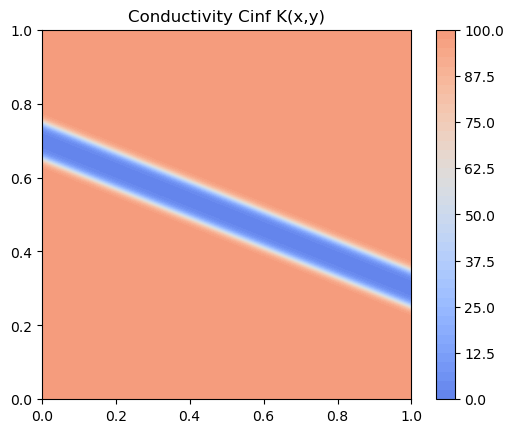

In [72]:
def plot_conductivity_Cinf(parameters):
    K = get_conductivity_Cinf(parameters)
    K_plot = project(K, V)

    p = plot(K_plot, cmap="coolwarm", vmin=0.-20, vmax=140.0)
    plt.colorbar(p)
    plt.title("Conductivity Cinf K(x,y)")

plot_conductivity_Cinf(example_parameters)


# En comparaison à avant :

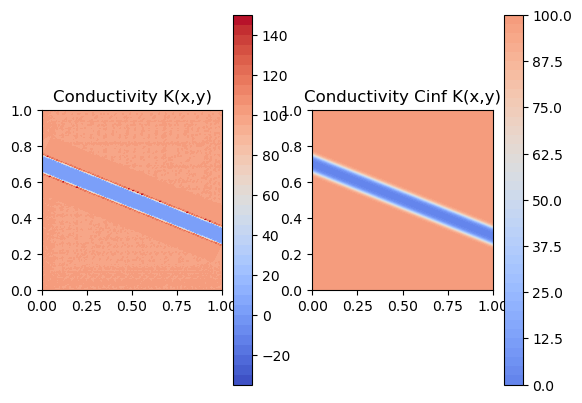

In [73]:
plt.subplot(1, 2, 1)
plot_conductivity(example_parameters)
plt.subplot(1, 2, 2)
plot_conductivity_Cinf(example_parameters)

In [74]:
A_mu_Cinf, b_mu_Cinf = get_stiffness_and_load_Cinf(example_parameters)
uh_HDM_sol_Cinf = Function(V)
solve(A_mu_Cinf, uh_HDM_sol_Cinf.vector(), b_mu_Cinf)
uh_HDM_sol_Cinf_vec = np.array(uh_HDM_sol_Cinf.vector().get_local()) + u_L_vect

A_mu_comparaison, b_mu_comparaison =get_stiffness_and_load(example_parameters)
uh_HDM_sol_comparaison = Function(V)
solve(A_mu_comparaison, uh_HDM_sol_comparaison.vector(), b_mu_comparaison)
uh_HDM_sol_comparaison_vec = np.array(uh_HDM_sol_comparaison.vector().get_local()) + u_L_vect

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


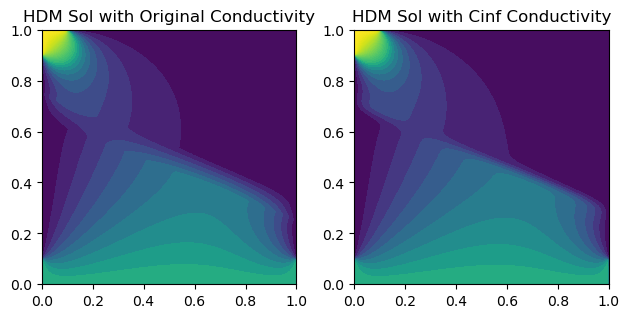

In [75]:
plt.subplot(1, 2, 1)
plot(uh_HDM_sol_comparaison, cmap="viridis", norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("HDM Sol with Original Conductivity")
plt.subplot(1, 2, 2)
plot(uh_HDM_sol_Cinf, cmap="viridis", norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("HDM Sol with Cinf Conductivity")
plt.tight_layout()
plt.show()


In [76]:
U_snapshot_non_lineaire_Cinf = np.zeros((N_dof, Ns_non_lineaire))
print("dimension de U_snapshot:", U_snapshot_non_lineaire_Cinf.shape)

dimension de U_snapshot: (160801, 200)


In [78]:
for i in tqdm(range(Ns_non_lineaire), desc="Génération des Snapshots"):
    A_mu, b_mu = get_stiffness_and_load(parameters_list_non_lineaire[i])
    uh_HDM_sol = Function(V)
    solve(A_mu, uh_HDM_sol.vector(), b_mu)
    uh_HDM_sol_vec = np.array(uh_HDM_sol.vector().get_local())
    U_snapshot_non_lineaire_Cinf[:, i] = uh_HDM_sol_vec


Génération des Snapshots: 100%|██████████| 200/200 [09:21<00:00,  2.81s/it]


In [79]:
U_nl_Cinf, S_nl_Cinf, Vt_nl_Cinf = np.linalg.svd(U_snapshot_non_lineaire_Cinf, full_matrices=False)

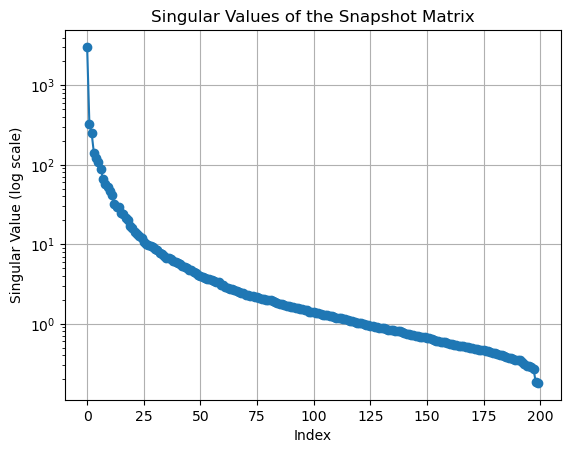

In [80]:
plt.semilogy(S_nl_Cinf, marker='o', label='Singular Values (Linear Snapshots)')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Snapshot Matrix')
plt.grid()
plt.show()

Energy percentage: [ 97.45766677  98.55517247  99.20002041  99.40524438  99.55735416
  99.6835646   99.76786392  99.81440192  99.84973637  99.8787759
  99.90126545  99.91922814  99.93025419  99.939496    99.94847794
  99.95497502  99.96100697  99.96571323  99.96996017  99.97301606
  99.97570156  99.97783816  99.97979466  99.9814426   99.98290882
  99.98412644  99.98522214  99.98623506  99.98719156  99.98810525
  99.98890859  99.98965782  99.99030347  99.99090305  99.99144377
  99.99192463  99.99238719  99.99282183  99.99323007  99.99359477
  99.99394054  99.99426984  99.99456558  99.99484074  99.99510405
  99.99534325  99.99557545  99.99578759  99.9959826   99.99615712
  99.99632339  99.99648353  99.99663246  99.9967745   99.99691278
  99.99704396  99.99717076  99.99729185  99.99740882  99.99750666
  99.99760396  99.99769442  99.9977795   99.99786009  99.99793656
  99.99800975  99.99807967  99.99814526  99.99820685  99.99826738
  99.99832394  99.99837889  99.99843127  99.9984835   99.9

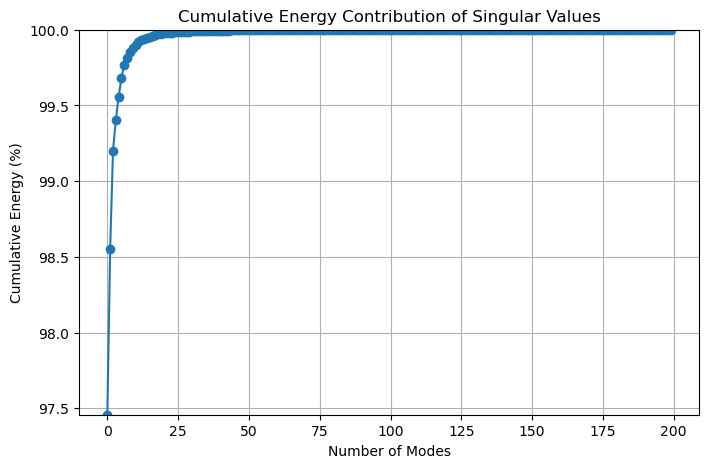

In [81]:
plot_energy_contribution(S_nl_Cinf)

In [140]:
error_A_non_lineaire_Cinf = np.zeros(len(Ns_non_lineaire_range))
error_L2_non_lineaire_Cinf = np.zeros(len(Ns_non_lineaire_range))
time_non_linear_Cinf = np.zeros(len(Ns_non_lineaire_range))


# ==========================================
# 0. TOUR DE CHAUFFE (WARM-UP)
# On force l'ordinateur à tout initialiser (FEniCS + NumPy) sur le plus gros cas pour preparer le cache et les compilations JIT, afin d'avoir des mesures de temps plus stables et représentatives lors du benchmark.
# ==========================================
print("Tour de chauffe en cours (compilation JIT et initialisation mémoire)...")
params_warmup = parameters_test_non_lineaire_list[0]
A_warmup, b_warmup = get_stiffness_and_load_Cinf(params_warmup)
u_full_warmup = Function(V)
solve(A_warmup, u_full_warmup.vector(), b_warmup) # Chauffe FEniCS

r_max = Ns_non_lineaire_range[-1] # On prend le plus gros r (ex: 50)
V_r_warmup = U_nl_Cinf[:, :r_max]
A_red_warmup = build_reduced_stiffness(A_warmup, V_r_warmup) # Chauffe la projection
b_red_warmup = build_reduced_load(b_warmup, V_r_warmup)
u_red_warmup = np.linalg.solve(A_red_warmup, b_red_warmup)   # Chauffe le solveur NumPy
_ = V_r_warmup.dot(u_red_warmup) + u_L_vect                  # Chauffe le produit matriciel
print("Tour de chauffe terminé ! Lancement du benchmark...")
# ==========================================
A_test_list_Cinf = []
b_test_list_Cinf = []
HF_sol_list_Cinf = []
for i, params in enumerate(parameters_test_non_lineaire_list):
    A_test, b_test = get_stiffness_and_load_Cinf(params)
    A_test_list_Cinf.append(A_test)
    b_test_list_Cinf.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_list_Cinf.append(u_full)




for j, r in enumerate(tqdm(Ns_non_lineaire_range, desc="Testing ROM with non-linear snapshots")):
    for i, params in enumerate(parameters_test_non_lineaire_list):
        A_test = A_test_list_Cinf[i]
        b_test = b_test_list_Cinf[i]
        u_full = HF_sol_list_Cinf[i]
        # ==========================================
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ==========================================
        t0 = time() 
        V_r = U_nl_Cinf[:, :r]
        A_red = build_reduced_stiffness(A_test, V_r)
        b_red = build_reduced_load(b_test, V_r)
        
        u_red = np.linalg.solve(A_red, b_red)
        u_approx = V_r.dot(u_red) + u_L_vect
        
        t1 = time() 
        # ==========================================
        # FIN DU CHRONO
        # ==========================================
        
        # 2. POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx, V, u_L_vect)
        error_A_non_lineaire_Cinf[j] += error_A_norm(u_full, u_approx_fenics, A_test)
        error_L2_non_lineaire_Cinf[j] += error_L2(u_full, u_approx_fenics)
        time_non_linear_Cinf[j] += (t1 - t0)

    # Moyenne sur les N_test paramètres
    error_A_non_lineaire_Cinf[j] /= len(parameters_test_non_lineaire_list) 
    error_L2_non_lineaire_Cinf[j] /= len(parameters_test_non_lineaire_list) 
    time_non_linear_Cinf[j] /= len(parameters_test_non_lineaire_list)
    


Tour de chauffe en cours (compilation JIT et initialisation mémoire)...
Tour de chauffe terminé ! Lancement du benchmark...


Testing ROM with non-linear snapshots: 100%|██████████| 21/21 [16:10<00:00, 46.21s/it]


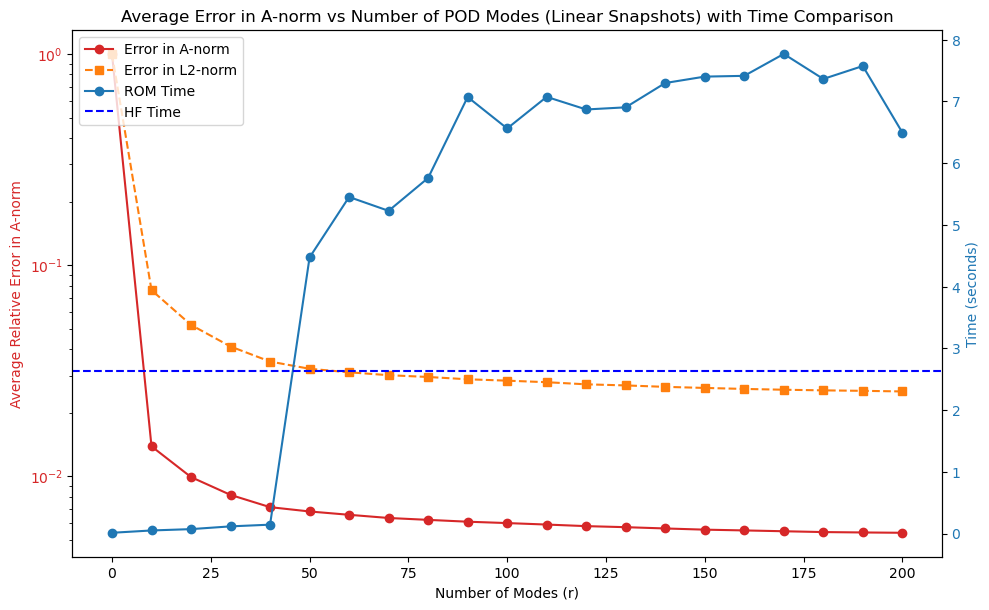

In [90]:
# Créer la figure et l'axe principal pour l'erreur
fig, ax1 = plt.subplots(figsize=(10, 6))
# Plotter l'erreur en norme A sur l'axe principal (gauche)
color = 'tab:red'
ax1.set_xlabel('Number of Modes (r)')
ax1.set_ylabel('Average Relative Error in A-norm', color=color)
ax1.semilogy(Ns_non_lineaire_range, error_A_non_lineaire, marker='o', color=color, label='Error in A-norm')
ax1.tick_params(axis='y', labelcolor=color)
# Plotter l'erreur en norme L2 sur l'axe principal (gauche)
color = 'tab:orange'
ax1.semilogy(Ns_non_lineaire_range, error_L2_non_lineaire, marker='s', color=color, linestyle='--', label='Error in L2-norm')
# Créer un deuxième axe y partagant la même échelle x
ax2 = ax1.twinx()
# Plotter le temps sur le deuxième axe (droite)
color = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color=color)
ax2.plot(Ns_non_lineaire_range, time_non_linear, marker='o', color=color, label='ROM Time')
ax2.axhline(y=HF_compution_time, color='b', linestyle='--', label='HF Time')
ax2.tick_params(axis='y', labelcolor=color)
# Ajouter une légende
fig.tight_layout()  # Ajuster la disposition pour éviter les chevauchements
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
# Ajouter un titre
plt.title('Average Error in A-norm vs Number of POD Modes (Linear Snapshots) with Time Comparison')
# Afficher le graphique
plt.show()

## L'EIM en $C^\infty$

In [91]:
def g_Cinf(mu):
    """
    Accepte mu sous forme de dictionnaire ou de liste/array.
    """
    if isinstance(mu, dict):
        # Si c'est déjà un dictionnaire, on l'utilise tel quel
        parameters = mu
    else:
        # Si c'est une liste, on la convertit
        parameters = {
            "slope": mu[0], 
            "position": mu[1], 
            "half_width": mu[2], 
            "D_background": mu[3], 
            "D_fracture": mu[4]
        }
        
    K = get_conductivity_Cinf(parameters)
    return project(K, V)


M_max = 400

MU_MIN = [
    20.0,
    50.0,
    3.0
]

# --- BORNES SUPÉRIEURES (MAX) ---
MU_MAX = [
    60.0,
    90.0,
    7.0
]

In [92]:
def compute_single_snapshot_Cinf(mu):
    # On appelle ta fonction g_Cinf(mu)
    G = g_Cinf(mu)
    return G.vector().get_local()

# --- CONFIGURATION ---
N_train = len(D_train)
print(f"Création de la Matrice : {N_train} paramètres.")

# ====================================================================
# L'AJOUT MAGIQUE : LE TIR D'ÉCHAUFFEMENT (PRÉ-COMPILATION)
# ====================================================================
print("Échauffement de FEniCS (Compilation JIT séquentielle)...")
# FEniCS va compiler tranquillement sur un seul coeur
_ = compute_single_snapshot_Cinf(D_train[0])
print("Compilation terminée ! Le cache est prêt pour la parallélisation.")

# ====================================================================
# LA BOUCLE PARALLÈLE
# ====================================================================
# Lancement avec le backend 'threading'
results = Parallel(n_jobs=-1, prefer="threads")(
    delayed(compute_single_snapshot_Cinf)(mu) for mu in tqdm(D_train, desc="Phase Offline Parallèle")
)

Snapshots_conductivite_Cinf = np.array(results)
print(f"\nTerminé ! Forme de la matrice : {Snapshots_conductivite_Cinf.shape}")

# Sauvegarde de sécurité vitale (pour ne pas pleurer si le notebook freeze plus tard)
np.save("snapshots_Cinf_backup.npy", Snapshots_conductivite_Cinf)

Création de la Matrice : 400 paramètres.
Échauffement de FEniCS (Compilation JIT séquentielle)...
Calling FFC just-in-time (JIT) compiler, this may take some time.
Compilation terminée ! Le cache est prêt pour la parallélisation.


Phase Offline Parallèle:   0%|          | 0/400 [00:00<?, ?it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.


Phase Offline Parallèle:   6%|▌         | 22/400 [00:03<00:56,  6.70it/s]

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
  Call

...

Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
    Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.


Phase Offline Parallèle:  99%|█████████▉| 396/400 [24:49<00:15,  3.88s/it]

Calling FFC just-in-time (JIT) compiler, this may take some time.


Phase Offline Parallèle: 100%|██████████| 400/400 [24:49<00:00,  3.72s/it]


  Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
  Calling FFC just-in-time (JIT) compiler, this may take some time.

Terminé ! Forme de la matrice : (400, 160801)


In [145]:
np.save("Snapshots_conductivite_Cinf.npy", Snapshots_conductivite_Cinf)

In [93]:
U_EIM_Cinf, S_EIM_Cinf, Vt_EIM_Cinf = np.linalg.svd(Snapshots_conductivite_Cinf, full_matrices=False)

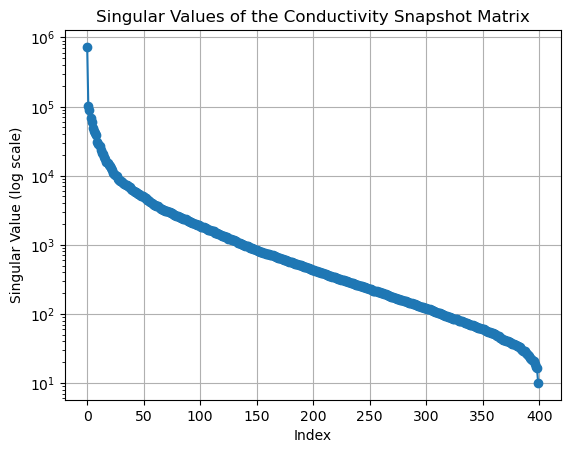

In [94]:
plt.semilogy(S_EIM_Cinf, marker='o', label='Singular Values (Conductivity Snapshots)')
plt.xlabel('Index')
plt.ylabel('Singular Value (log scale)')
plt.title('Singular Values of the Conductivity Snapshot Matrix')
plt.grid()
plt.show()

Energy percentage: [ 92.74296948  94.54539015  95.89906852  96.71854595  97.32631903
  97.73353497  98.07264633  98.37578442  98.63340329  98.79416338
  98.93454051  99.05704544  99.15264212  99.23071156  99.30576106
  99.36568282  99.41788823  99.46260835  99.50437636  99.53973135
  99.57408747  99.6033467   99.62799639  99.64939231  99.66873861
  99.68680793  99.70382882  99.71791404  99.73058126  99.74319146
  99.75572136  99.76720062  99.77825232  99.78857102  99.79825905
  99.80773838  99.81658314  99.8250068   99.83314928  99.84032364
  99.84685211  99.85312754  99.85910767  99.86484485  99.87052322
  99.8757499   99.88081951  99.88562736  99.89013364  99.89449672
  99.89858757  99.90260606  99.906507    99.90997123  99.91337049
  99.91651463  99.91947798  99.92238143  99.92505698  99.92758249
  99.92997873  99.93235702  99.93466208  99.93691731  99.93899318
  99.94094387  99.9428129   99.94459189  99.94635121  99.94804149
  99.94971222  99.95134065  99.95293532  99.95446415  99.

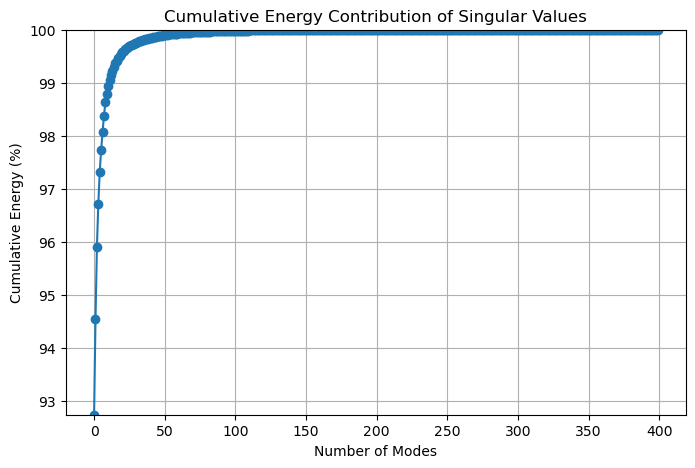

In [95]:
plot_energy_contribution(S_EIM_Cinf)

In [96]:

nb_dofs_Cinf = V.dim()

Q_Cinf = np.zeros((M_max, nb_dofs_Cinf))  # Base de fonctions q_m (normalisées)
Magic_Points_Cinf = []                   # Ensemble des t_m (les indices)
S_mu_Cinf = []                           # Paramètres sélectionnés

# Ps on remarque que les coeffs de l'articles B_ij^M sont indépendant de M donc on peut faire que une matrice 
B_complet_Cinf = np.zeros((M_max, M_max))
print("Lancement de l'algorithme DEIM (SVD + Magic Points)...")

for m in tqdm(range(M_max), desc="Construction de la base DEIM"):
    
    # =======================================================
    # 1. SÉLECTION DU MODE (Fini le Greedy, merci la SVD !)
    # =======================================================
    # Le m-ième mode spatial dominant est simplement la m-ième ligne de Vt_EIM
    xi_M = Vt_EIM_Cinf[m, :]

    # =======================================================
    # 2. CONSTRUCTION DU NOUVEAU MODE EIM/DEIM
    # =======================================================
    if m == 0:
        # Premier mode
        t_1 = np.argmax(np.abs(xi_M))
        q_1 = xi_M / xi_M[t_1]
        
        Magic_Points_Cinf.append(t_1)
        Q_Cinf[0, :] = q_1
        B_complet_Cinf[0, 0] = 1.0
        
    else:
        # Modes suivants
        T_current = Magic_Points_Cinf[:m]
        
        # Résolution pour trouver le résidu
        xi_magic = xi_M[T_current]
        sigma = np.linalg.solve(B_complet_Cinf[:m, :m], xi_magic)
        
        # Le fameux résidu r_M
        r_M = xi_M - (sigma @ Q_Cinf[:m, :])
        
        # Le nouveau Magic Point t_M
        t_M = np.argmax(np.abs(r_M))
        Magic_Points_Cinf.append(t_M)
        
        # La nouvelle base q_M normalisée
        q_M = r_M / r_M[t_M]
        Q_Cinf[m, :] = q_M
        
        # Mise à jour de la matrice B
        for i in range(m + 1):
            for j in range(m + 1):
                B_complet_Cinf[i, j] = Q_Cinf[j, Magic_Points_Cinf[i]]


print("\nBase DEIM générée avec succès !")

Lancement de l'algorithme DEIM (SVD + Magic Points)...


Construction de la base DEIM: 100%|██████████| 400/400 [00:11<00:00, 35.46it/s] 


Base DEIM générée avec succès !


In [114]:
import scipy.sparse as sp

In [115]:
def build_reduced_stiffness_sparse(A_fenics, V_r):
    # 1. On récupère le backend mathématique (PETSc)
    A_mat = as_backend_type(A_fenics).mat()
    
    # 2. On extrait les données sous forme creuse (Sparse CSR)
    # C'est instantané et ça prend zéro mémoire !
    row, col, data = A_mat.getValuesCSR()
    A_sparse = sp.csr_matrix((data, col, row), shape=A_mat.getSize())
    
    # 3. On multiplie la matrice creuse par la base dense V_r
    # L'ordre optimal : A * V_r (donne une matrice N x r), puis V_r.T * résultat
    temp = A_sparse.dot(V_r) 
    A_red = np.dot(V_r.T, temp) 
    
    return A_red

def build_reduced_load_sparse(b_fenics, V_r):
    # Pour un vecteur, c'est direct et rapide
    b_array = b_fenics.get_local()
    b_red = np.dot(V_r.T, b_array)
    return b_red

In [151]:
r_EIM = 100 
V_r = U_nl_Cinf[:, :r_EIM]

In [ ]:


print("Extraction du terme source constant (K = 0)...")
_, b_zero_HF = get_A_b_EIM(np.zeros(V.dim()))
b_source_red = build_reduced_load(b_zero_HF, V_r)

# =======================================================
# L'OPTIMISATION FENICS (Le secret de la vitesse)
# =======================================================
# 1. On crée une coquille vide pour la conductivité
K_mode_func = Function(V)

# 2. On définit les fonctions de base (UNE SEULE FOIS)
u = TrialFunction(V)
v = TestFunction(V)

# 3. On écrit la formule mathématique (UNE SEULE FOIS)
# (Assure-toi que cette formule correspond bien à ton équation de Darcy)
a_form = K_mode_func * inner(grad(u), grad(v)) * dx

# Si tu as un terme de bord (Neumann) ou autre qui dépend de K, il faut l'ajouter dans L_form.
# Mais comme ton second membre a été géré via ta méthode u_L, 
# tu peux souvent récupérer le "b" modifié via ta fonction get_A_b_EIM existante 
# ou l'assembler ici si tu sais comment elle est faite. 
# Pour rester compatible avec ton code, on va optimiser au moins la partie A :

A_reduit_EIM_Cinf_list = []
b_reduit_EIM_Cinf_list = []

print("Projection hors-ligne (Optimisée FEniCS)...")
t_start = time()

for m in tqdm(range(400), desc="Calcul EIM Optimisé"):
    q_m = Q_Cinf[m, :]   
    
    # Injection ultra-rapide
    K_mode_func.vector()[:] = q_m
    A_EIM = assemble(a_form)
    
    # (Assemblage de b_EIM ici...)
    _, b_EIM = get_A_b_EIM(q_m) 
    
    # PROJECTION CREUSE (La vitesse de l'éclair)
    A_red_EIM = build_reduced_stiffness_sparse(A_EIM, V_r)
    b_red_EIM = build_reduced_load_sparse(b_EIM, V_r)
    
    A_reduit_EIM_Cinf_list.append(A_red_EIM)
    b_reduit_EIM_Cinf_list.append(b_red_EIM)

Extraction du terme source constant (K = 0)...
Projection hors-ligne (Optimisée FEniCS)...


Calcul EIM Optimisé: 100%|██████████| 400/400 [41:49<00:00,  6.27s/it]


In [144]:
np.save("A_reduit_EIM.npy", A_reduit_EIM_Cinf_list)

In [160]:
M_EIM = range(1, 401, 10) 


In [ ]:
error_L2_EIM_Cinf = np.zeros(len(M_EIM))
time_EIM_Cinf = np.zeros(len(M_EIM))

A_test_list_Cinf = []
b_test_list_Cinf = []
HF_sol_list_Cinf = []
g_test_list_Cinf = []

print("Pré-calcul des solutions HF et des champs de conductivité...")
for i, params in enumerate(tqdm(parameters_test_non_lineaire_list, desc="Pré-calcul FEniCS")):
    # On calcule la matrice et le second membre
    A_test, b_test = get_stiffness_and_load_Cinf(params)
    A_test_list_Cinf.append(A_test)
    b_test_list_Cinf.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_list_Cinf.append(u_full)
    
    # On paie le prix de FEniCS (project) UNE SEULE FOIS par paramètre
    G_array = g_Cinf(params).vector().get_local()
    g_test_list_Cinf.append(G_array)

Pré-calcul des solutions HF et des champs de conductivité...


Pré-calcul FEniCS: 100%|██████████| 10/10 [01:00<00:00,  6.01s/it]


In [148]:
A_test_list_heaviside = []
b_test_list_heaviside = []
HF_sol_list_heaviside = []
g_test_list_heaviside = []

print("Pré-calcul des solutions HF et des champs de conductivité...")
for i, params in enumerate(tqdm(parameters_test_non_lineaire_list, desc="Pré-calcul FEniCS")):
    # On calcule la matrice et le second membre
    A_test, b_test = get_stiffness_and_load_Cinf(params)
    A_test_list_heaviside.append(A_test)
    b_test_list_heaviside.append(b_test)
    
    # Résolution Haute Fidélité (FOM) de référence
    u_full = Function(V)
    solve(A_test, u_full.vector(), b_test) 
    HF_sol_list_heaviside.append(u_full)
    
    # On paie le prix de FEniCS (project) UNE SEULE FOIS par paramètre
    G_array = g_Cinf(params).vector().get_local()
    g_test_list_heaviside.append(G_array)

Pré-calcul des solutions HF et des champs de conductivité...


Pré-calcul FEniCS: 100%|██████████| 10/10 [00:49<00:00,  4.99s/it]


In [118]:
# On extrait les coordonnées géométriques de tous les degrés de liberté (1 seule fois)
dof_coords = V.tabulate_dof_coordinates()

def g_point_Cinf(mu, point_idx):
    """
    Évalue la conductivité EXACTEMENT au noeud spatial point_idx.
    Temps d'exécution : ~0.0001s.
    """
    if isinstance(mu, dict):
        parameters = mu
    else:
        parameters = {
            "slope": mu[0], "position": mu[1], "half_width": mu[2], 
            "D_background": mu[3], "D_fracture": mu[4]
        }
    
    K = get_conductivity_Cinf(parameters)
    coord = dof_coords[point_idx]
    
    try:
        # L'étoile (*) est magique : elle déballe le tableau [x, y] en arguments K(x, y)
        return K(*coord)
    except Exception:
        # Code de secours robuste qui attrape TOUTES les erreurs (ValueError, TypeError, etc.)
        val = np.zeros(1)
        K.eval(val, coord)
        return val[0]

Calcul EIM:  14%|█▎        | 54/400 [56:21<6:01:07, 62.62s/it]


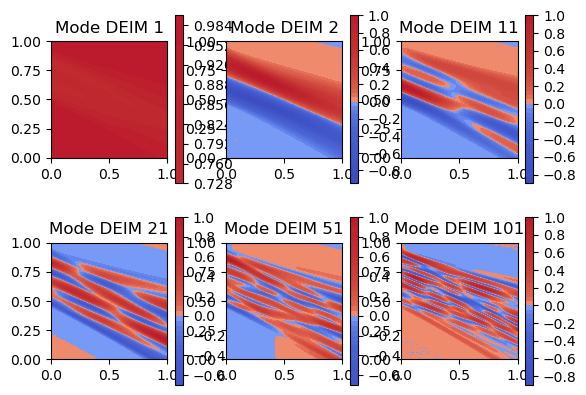

In [119]:
# Visualisation des modes EIM
for j, i in enumerate([0, 1, 10, 20, 50, 100]):  # Quelques indices de modes à visualiser
    mode_fenics = numpy_to_fenics_param(Q_Cinf[i, :], V)
    plt.subplot(2, 3, j+1)
    p = plot(mode_fenics,
             cmap="coolwarm", 
             norm=colors.SymLogNorm(linthresh=1e-3, vmin=-1.0, vmax=1.5))
    plt.colorbar(p)
    plt.title(f"Mode DEIM {i+1}")


Visualisation de l'approximation EIM pour un paramètre réel:   0%|          | 0/5 [00:00<?, ?it/s]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


Visualisation de l'approximation EIM pour un paramètre réel:  20%|██        | 1/5 [00:02<00:10,  2.62s/it]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


Visualisation de l'approximation EIM pour un paramètre réel:  40%|████      | 2/5 [00:05<00:07,  2.59s/it]

...

Visualisation de l'approximation EIM pour un paramètre réel:  60%|██████    | 3/5 [00:07<00:05,  2.58s/it]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


Visualisation de l'approximation EIM pour un paramètre réel:  80%|████████  | 4/5 [00:10<00:02,  2.59s/it]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


Visualisation de l'approximation EIM pour un paramètre réel: 100%|██████████| 5/5 [00:13<00:00,  2.62s/it]


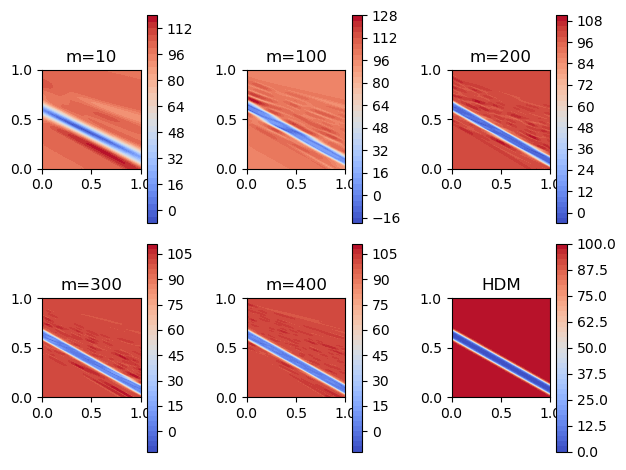

In [101]:
G_param = parameters_test_non_lineaire_list[2]
erreur_conductivite = np.zeros(len([10, 100, 200, 300, 400]))
K_param = get_conductivity_Cinf(G_param)
K_fenics = project(K_param, V)
K_vect = K_fenics.vector().get_local()
for j, m in enumerate(tqdm([10, 100, 200, 300, 400], desc="Visualisation de l'approximation EIM pour un paramètre réel")):
    G = np.array([K_vect[Magic_Points_Cinf[k]] for k in range(m)])
    beta = np.linalg.solve(B_complet_Cinf[:m, :m], G)
    g_f = beta @ Q_Cinf[:m, :]
    g_f_fenics = numpy_to_fenics_param(g_f, V)
    erreur_conductivite[j] = errornorm(K_fenics, g_f_fenics, 'L2')
    plt.subplot(2, 3, j+1)
    p = plot(g_f_fenics,
             cmap="coolwarm")
    plt.colorbar(p)
    plt.title(f"m={m}")


plt.subplot(2, 3, 6)
p = plot(K_fenics,
             cmap="coolwarm")
plt.colorbar(p)
plt.title("HDM")
plt.tight_layout()
plt.show()

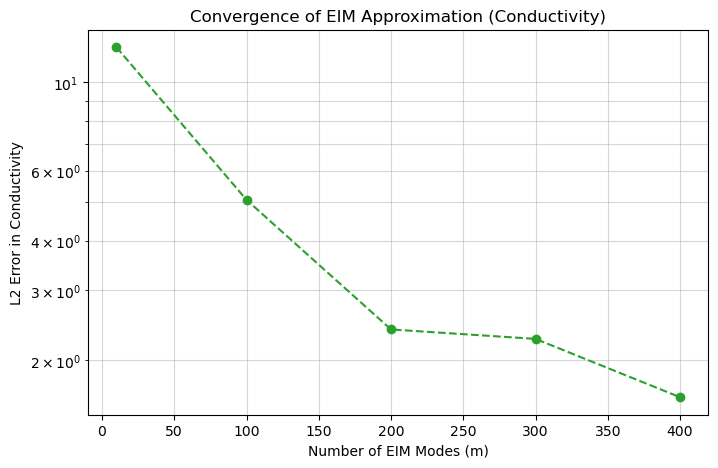

In [102]:
plt.figure(figsize=(8, 5))
plt.semilogy([10, 100, 200, 300, 400], erreur_conductivite, marker='o', color='tab:green', linestyle='--')
plt.xlabel('Number of EIM Modes (m)')
plt.ylabel('L2 Error in Conductivity')
plt.title('Convergence of EIM Approximation (Conductivity)')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [152]:
print("\nLancement du benchmark Online EIM...")

error_A_norm_EIM_Cinf = np.zeros(len(M_EIM))
error_A_norm_EIM_Cinf_heaviside = np.zeros(len(M_EIM))
error_L2_EIM_Cinf_heaviside = np.zeros(len(M_EIM))

for j, m in enumerate(tqdm(M_EIM, desc="Testing ROM with EIM")):
    
    for i, params in enumerate(parameters_test_non_lineaire_list):
        A_test_norme = A_test_list_Cinf[i]
        A_test_norme_heaviside = A_test_list_heaviside[i]
        # Récupération de la conductivité de test pré-calculée
        g_mu_complet = g_test_list_Cinf[i]

        # ----------------------------------------------------
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ----------------------------------------------------
        t0 = time()
        
        # 1. On extrait comme de vrais "capteurs" physiques sur les Magic Points
        G = np.array([g_mu_complet[Magic_Points_Cinf[k]] for k in range(m)])
        
        # 2. Calcul des coefficients EIM
        beta = np.linalg.solve(B_complet_Cinf[:m, :m], G) 
        
        # 3. Assemblage réduit EIM pour la matrice A
        A_red_EIM = np.sum([beta[k] * A_reduit_EIM_Cinf_list[k] for k in range(m)], axis=0)
        
        # 4. CORRECTION MAGIQUE SUR LE SECOND MEMBRE b
        # On somme les parties qui dépendent VRAIMENT de la conductivité (conditions aux limites)
        b_var_EIM = np.sum([beta[k] * (b_reduit_EIM_Cinf_list[k] - b_source_red) for k in range(m)], axis=0)
        # Et on ajoute le terme source constant UNE SEULE FOIS
        b_red_EIM = b_source_red + b_var_EIM

        # 5. Résolution du petit système réduit
        u_red_EIM = np.linalg.solve(A_red_EIM, b_red_EIM)
        # 6. Reconstruction rapide NumPy
        u_approx_EIM = V_r.dot(u_red_EIM) + u_L_vect
        
        t1 = time()
        # ----------------------------------------------------
        # FIN DU CHRONO
        # ----------------------------------------------------
        
        # POST-TRAITEMENT ET ERREUR (Hors chrono ROM)
        u_approx_fenics = numpy_to_fenics(u_approx_EIM, V, u_L_vect) 
        
        # (Correction ici : on utilise bien HF_sol_list_Cinf)
        u_full = HF_sol_list_Cinf[i] 
        u_full_heaviside = HF_sol_list_heaviside[i]
        error_A_norm_EIM_Cinf[j] += error_A_norm(u_full, u_approx_fenics, A_test_norme)
        error_A_norm_EIM_Cinf[j] += error_A_norm(u_full_heaviside, u_approx_fenics, A_test_norme_heaviside)
        error_L2_EIM_Cinf[j] += error_L2(u_full, u_approx_fenics)
        error_L2_EIM_Cinf_heaviside[j] += error_L2(u_full_heaviside, u_approx_fenics)
        time_EIM_Cinf[j] += (t1 - t0)

    # Moyennes
    error_A_norm_EIM_Cinf[j] /= len(parameters_test_non_lineaire_list)
    error_L2_EIM_Cinf[j] /= len(parameters_test_non_lineaire_list)
    error_A_norm_EIM_Cinf_heaviside[j] /= len(parameters_test_non_lineaire_list)
    error_L2_EIM_Cinf_heaviside[j] /= len(parameters_test_non_lineaire_list)
    time_EIM_Cinf[j] /= len(parameters_test_non_lineaire_list)
    



Lancement du benchmark Online EIM...


Testing ROM with EIM: 100%|██████████| 40/40 [00:30<00:00,  1.30it/s]


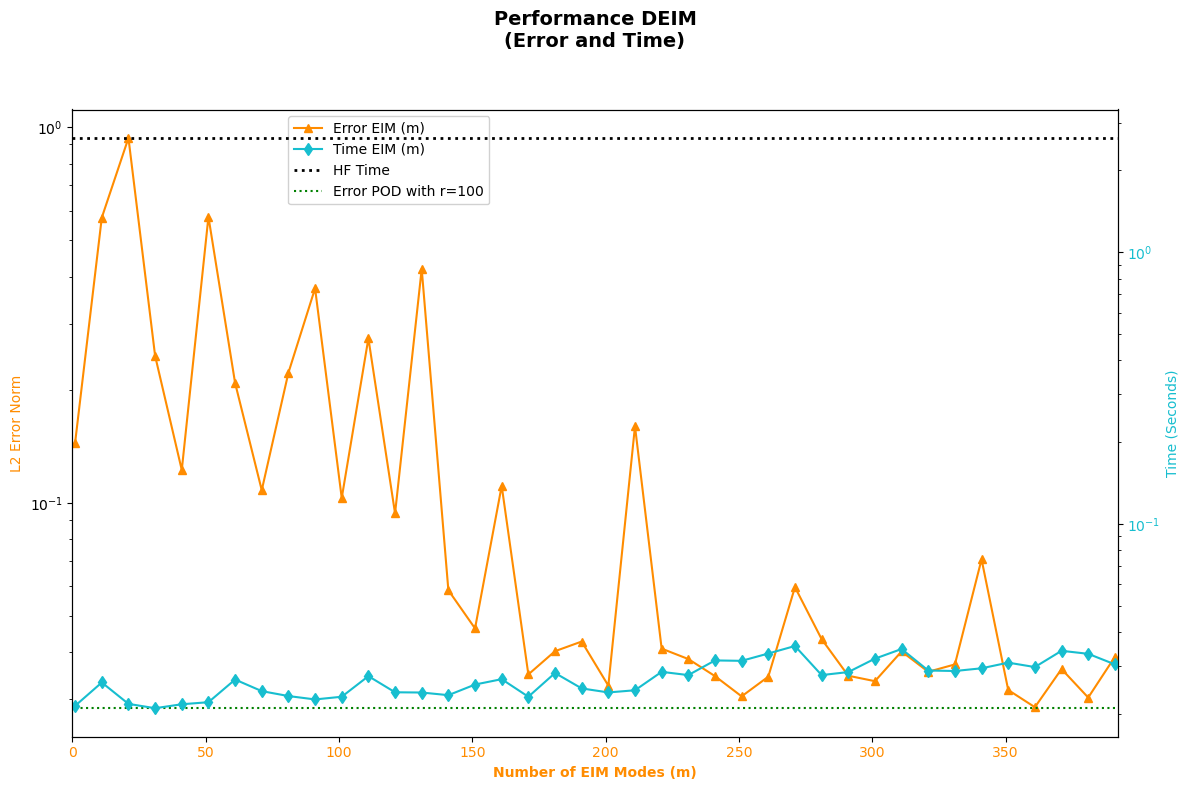

In [141]:

# Créer la figure
fig, ax1 = plt.subplots(figsize=(12, 8))

# =========================================================
# AXE Y GAUCHE : ERREURS (Norme A)
# =========================================================

# Erreur EIM (Bas / Gauche) -> Utilise l'axe Y gauche (ax1)
color_err_eim = 'darkorange'
ax1.set_xlabel('Number of EIM Modes (m)', color=color_err_eim, fontweight='bold')
l3, = ax1.semilogy(M_EIM, error_L2_EIM_Cinf, marker='^', 
               color=color_err_eim, label='Error EIM (m)')
ax1.tick_params(axis='x', labelcolor=color_err_eim)
ax1.set_ylabel('L2 Error Norm', color=color_err_eim)

# Ajout de la valeur théorique optimale en pointillés
l_opt = ax1.semilogy(M_EIM, [error_L2_non_lineaire_Cinf[10] for r_EIM in M_EIM], 
                 marker='', linestyle=':', color='green', label='Error POD with r=100')

# =========================================================
# AXE Y DROIT : TEMPS (Secondes)
# =========================================================

ax2 = ax1.twinx()  # Partage l'axe X mais crée un nouvel axe Y droit
color_time_eim = 'tab:cyan'
l4, = ax2.semilogy(M_EIM, time_EIM_Cinf, marker='d', 
                   color=color_time_eim, label='Time EIM (m)')
ax2.tick_params(axis='y', labelcolor=color_time_eim)
ax2.set_ylabel('Time (Seconds)', color=color_time_eim)

# Ligne de référence HF
l_hf = ax2.axhline(y=HF_compution_time, color='black', linestyle=':', linewidth=2, label='HF Time')

# =========================================================
# AJUSTEMENTS ESTHÉTIQUES ET LÉGENDE
# =========================================================



# IMPORTANT : Synchroniser les limites des axes X du haut (m) pour superposer les points
ax1.set_xlim(min(M_EIM)-1, max(M_EIM)+1)
ax2.set_xlim(min(M_EIM)-1, max(M_EIM)+1)

# Regrouper toutes les lignes dans une seule et belle légende
lines = [l3, l4, l_hf, l_opt[0]]
labels = [l.get_label() for l in lines]
# On place la légende à un endroit qui gêne le moins (à adapter selon tes courbes)
ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.2, 1), framealpha=0.9)

# Titre général (pad éloigne le titre de l'axe supérieur)
plt.title('Performance DEIM\n(Error and Time)', pad=45, fontsize=14, fontweight='bold')

fig.tight_layout()
plt.show()

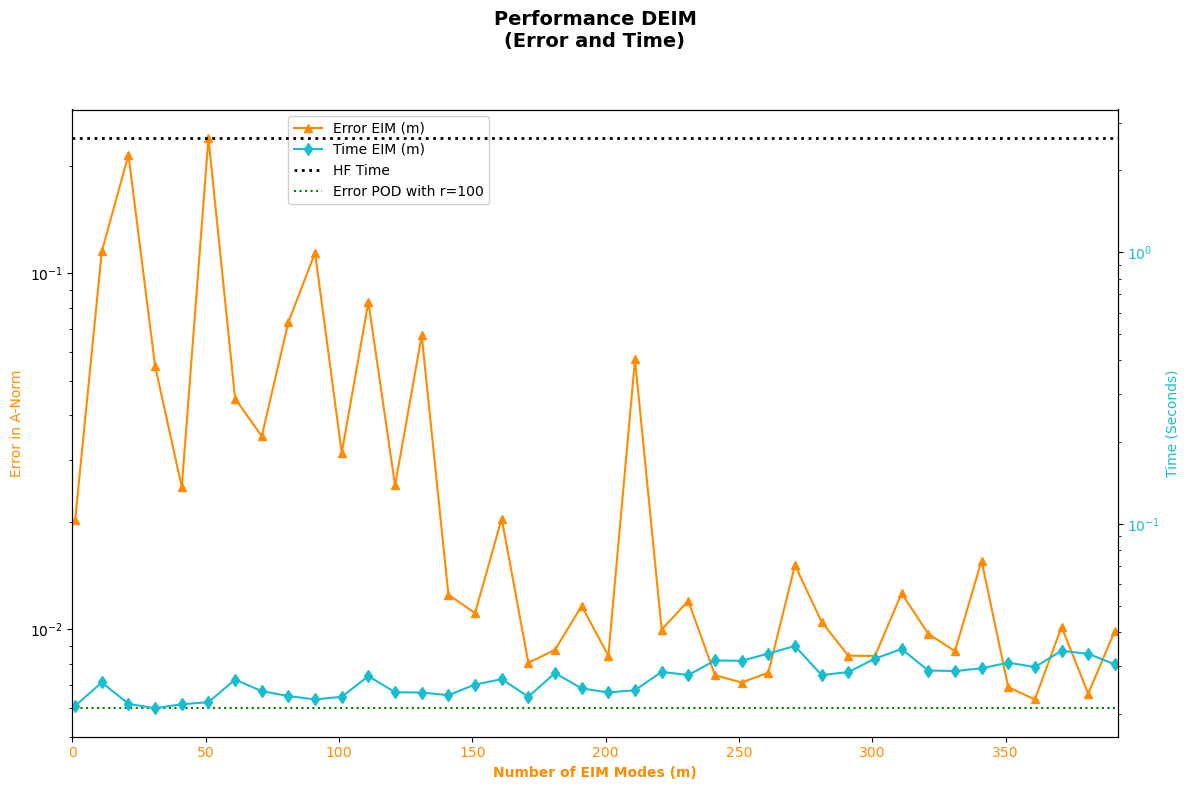

In [142]:
# Créer la figure
fig, ax1 = plt.subplots(figsize=(12, 8))

# =========================================================
# AXE Y GAUCHE : ERREURS (Norme A)
# =========================================================

# Erreur EIM (Bas / Gauche) -> Utilise l'axe Y gauche (ax1)
color_err_eim = 'darkorange'
ax1.set_xlabel('Number of EIM Modes (m)', color=color_err_eim, fontweight='bold')
l3, = ax1.semilogy(M_EIM, error_A_norm_EIM_Cinf, marker='^', 
               color=color_err_eim, label='Error EIM (m)')
ax1.tick_params(axis='x', labelcolor=color_err_eim)
ax1.set_ylabel('Error in A-Norm', color=color_err_eim)

# Ajout de la valeur théorique optimale en pointillés
l_opt = ax1.semilogy(M_EIM, [error_A_non_lineaire_Cinf[10] for r_EIM in M_EIM], 
                 marker='', linestyle=':', color='green', label='Error POD with r=100')

# =========================================================
# AXE Y DROIT : TEMPS (Secondes)
# =========================================================

ax2 = ax1.twinx()  # Partage l'axe X mais crée un nouvel axe Y droit
color_time_eim = 'tab:cyan'
l4, = ax2.semilogy(M_EIM, time_EIM_Cinf, marker='d', 
                   color=color_time_eim, label='Time EIM (m)')
ax2.tick_params(axis='y', labelcolor=color_time_eim)
ax2.set_ylabel('Time (Seconds)', color=color_time_eim)

# Ligne de référence HF
l_hf = ax2.axhline(y=HF_compution_time, color='black', linestyle=':', linewidth=2, label='HF Time')

# =========================================================
# AJUSTEMENTS ESTHÉTIQUES ET LÉGENDE
# =========================================================



# IMPORTANT : Synchroniser les limites des axes X du haut (m) pour superposer les points
ax1.set_xlim(min(M_EIM)-1, max(M_EIM)+1)
ax2.set_xlim(min(M_EIM)-1, max(M_EIM)+1)

# Regrouper toutes les lignes dans une seule et belle légende
lines = [l3, l4, l_hf, l_opt[0]]
labels = [l.get_label() for l in lines]
# On place la légende à un endroit qui gêne le moins (à adapter selon tes courbes)
ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.2, 1), framealpha=0.9)

# Titre général (pad éloigne le titre de l'axe supérieur)
plt.title('Performance DEIM\n(Error and Time)', pad=45, fontsize=14, fontweight='bold')

fig.tight_layout()
plt.show()

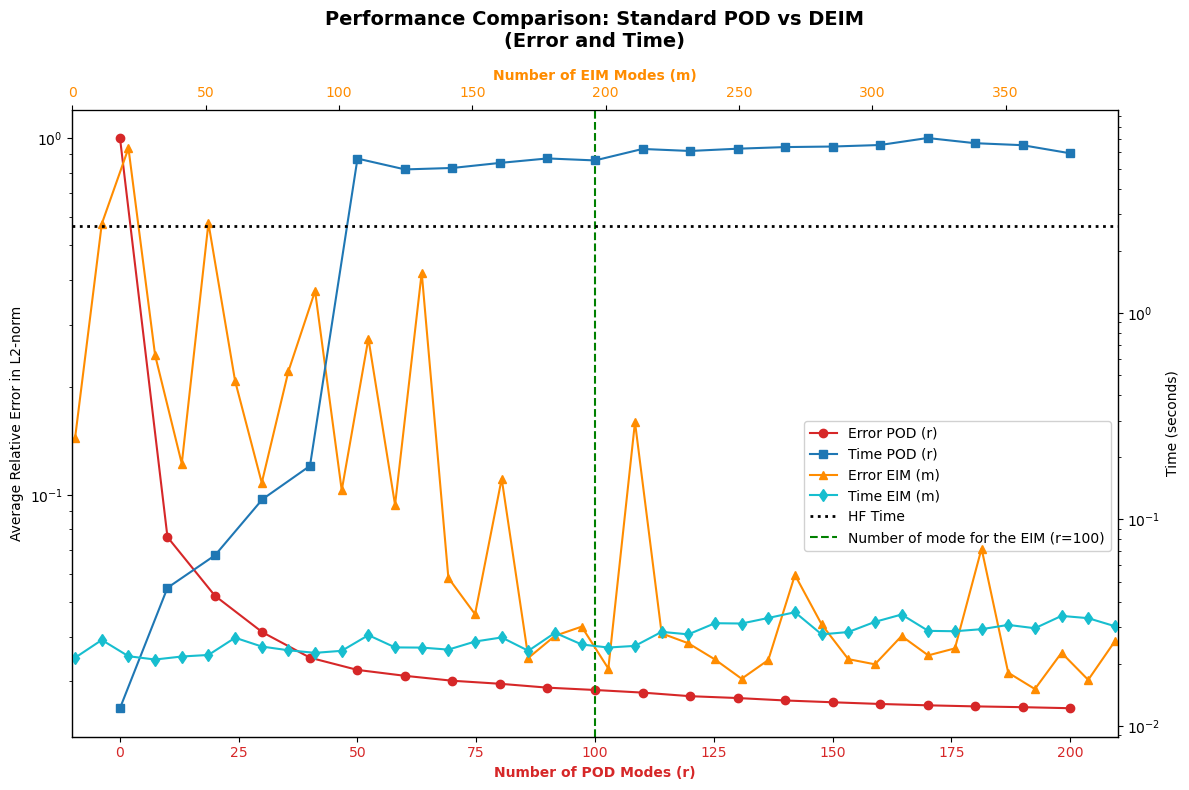

In [147]:

# Créer la figure
fig, ax1 = plt.subplots(figsize=(12, 8))

# =========================================================
# AXE Y GAUCHE : ERREURS (Norme A)
# =========================================================

# 1. Erreur POD pure (Bas / Gauche)
color_err_pod = 'tab:red'
ax1.set_xlabel('Number of POD Modes (r)', color=color_err_pod, fontweight='bold')
ax1.set_ylabel('Average Relative Error in L2-norm', color='black')
l1, = ax1.semilogy(Ns_non_lineaire_range, error_L2_non_lineaire_Cinf, marker='o', 
                   color=color_err_pod, label='Error POD (r)')
ax1.tick_params(axis='x', labelcolor=color_err_pod)

l5 =ax1.axvline(x=100, color='green', linestyle='--', label='Number of mode for the EIM (r=100)')

# 2. Erreur EIM (Haut / Gauche) -> Partage l'axe Y gauche (ax1.twiny)
ax3 = ax1.twiny()
color_err_eim = 'darkorange'
ax3.set_xlabel('Number of EIM Modes (m)', color=color_err_eim, fontweight='bold')
l3, = ax3.semilogy(M_EIM, error_L2_EIM_Cinf, marker='^', 
                   color=color_err_eim, label='Error EIM (m)')
ax3.tick_params(axis='x', labelcolor=color_err_eim)


# =========================================================
# AXE Y DROIT : TEMPS (Secondes)
# =========================================================

# 3. Temps POD pure (Bas / Droite) -> Partage l'axe X bas (ax1.twinx)
ax2 = ax1.twinx()
color_time_pod = 'tab:blue'
ax2.set_ylabel('Time (seconds)', color='black')
# J'ai mis semilogy ici pour que les temps soient comparables, tu peux remettre .plot si besoin
l2, = ax2.semilogy(Ns_non_lineaire_range, time_non_linear_Cinf, marker='s', 
                   color=color_time_pod, label='Time POD (r)')

# Ligne de référence HF
l_hf = ax2.axhline(y=HF_compution_time, color='black', linestyle=':', linewidth=2, label='HF Time')

# 4. Temps EIM (Haut / Droite) -> Partage l'axe Y droit et crée un nouvel axe X (ax2.twiny)
ax4 = ax2.twiny()
color_time_eim = 'tab:cyan'
l4, = ax4.semilogy(M_EIM, time_EIM_Cinf, marker='d',
                   color=color_time_eim, label='Time EIM (m)')

# =========================================================
# AJUSTEMENTS ESTHÉTIQUES ET LÉGENDE
# =========================================================

# Cacher la graduation X de ax4 car ax3 affiche déjà l'échelle "m" en haut
ax4.set_xticks([])
ax4.spines['top'].set_visible(False)

# IMPORTANT : Synchroniser les limites des axes X du haut (m) pour superposer les points
ax3.set_xlim(min(M_EIM)-1, max(M_EIM)+1)
ax4.set_xlim(min(M_EIM)-1, max(M_EIM)+1)

# Regrouper toutes les lignes dans une seule et belle légende
lines = [l1, l2, l3, l4, l_hf, l5]
labels = [l.get_label() for l in lines]
# On place la légende à un endroit qui gêne le moins (à adapter selon tes courbes)
ax1.legend(lines, labels, loc='center right', bbox_to_anchor=(1, 0.4), framealpha=0.9)

# Titre général (pad éloigne le titre de l'axe supérieur)
plt.title('Performance Comparison: Standard POD vs DEIM\n(Error and Time)', pad=45, fontsize=14, fontweight='bold')

fig.tight_layout()
plt.show()

In [136]:
V_r.shape

(160801, 100)

évolution de la solution approchée en fonction du nombre de modes EIM :


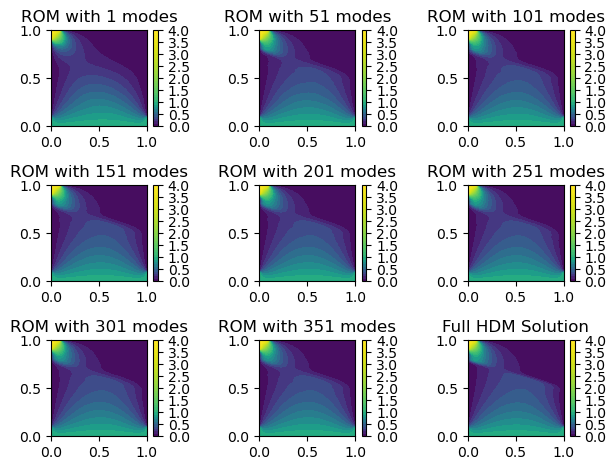

In [138]:
print("évolution de la solution approchée en fonction du nombre de modes EIM :")
for j, m in enumerate(range(1, 401, 50)):
    g_mu_complet = g_test_list_Cinf[4]  # On prend le premier cas de test pour visualiser l'évolution

        # ----------------------------------------------------
        # DÉBUT DU CHRONO : PHASE ONLINE ROM STRICTE
        # ----------------------------------------------------
        
        # On extrait comme de vrais "capteurs" physiques sur les Magic Points
    G = np.array([g_mu_complet[Magic_Points_Cinf[k]] for k in range(m)])
        
        # Calcul des coefficients EIM (B[m-1] car l'index commence à 0)
    beta = np.linalg.solve(B_complet_Cinf[:m, :m], G) # orriginal 
        #beta = np.linalg.lstsq(B_complet_Cinf[:m, :m], G, rcond=None)[0] # Solution plus stable numériquement
        
        # Assemblage réduit EIM (Combinaison linéaire pure NumPy)
    A_red_EIM = np.sum([beta[k] * A_reduit_EIM_Cinf_list[k] for k in range(m)], axis=0)
    b_var_EIM = np.sum([beta[k] * (b_reduit_EIM_Cinf_list[k] - b_source_red) for k in range(m)], axis=0)
        # Et on ajoute le terme source constant UNE SEULE FOIS
    b_red_EIM = b_source_red + b_var_EIM
        # Résolution du petit système réduit
    u_red_EIM = np.linalg.solve(A_red_EIM, b_red_EIM)
        
        # Reconstruction rapide NumPy
    u_approx_EIM = V_r.dot(u_red_EIM) + u_L_vect

    u_approx_fenics = numpy_to_fenics(u_approx_EIM, V, u_L_vect) 

    plt.subplot(3, 3, j + 1)
    p = plot(u_approx_fenics, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
    plt.title(f"ROM with {m} modes")
    plt.colorbar(p, fraction=0.046, pad=0.04)
plt.subplot(3, 3, 9)
u_full = HF_sol_list_Cinf[4]  # Solution HDM de référence pour le même cas de test
p = plot(u_full, 
          cmap="viridis", 
          norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("Full HDM Solution")
plt.colorbar(p, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [139]:
# =========================================================
# CONFIGURATION DU TEST DE VÉRIFICATION
# =========================================================
r_verif = 100
V_r_verif = U_nl_Cinf[:, :r_verif]  # La fameuse base spatiale à tester

# On renomme les variables pour ne pas écraser tes autres tests
M_EIM_verif = [10, 40, 100, 150, 200, 400]
error_L2_Reconstruct_Cinf = np.zeros(len(M_EIM_verif))
time_Reconstruct_Cinf = np.zeros(len(M_EIM_verif))

print(f"Lancement du test de 'Reconstruction -> Réduction' (r = {r_verif})...")

for j, m in enumerate(tqdm(M_EIM_verif, desc="Testing Assemble-then-Reduce")):
    
    for i, params in enumerate(parameters_test_non_lineaire_list):

        # Récupération de la conductivité de test (le snapshot pur)
        g_mu_complet = g_test_list_Cinf[i]

        t0 = time()
        
        # ----------------------------------------------------
        # ÉTAPE 1 : Reconstruction parfaite de la conductivité (Courbe Verte)
        # ----------------------------------------------------
        G = np.array([g_mu_complet[Magic_Points_Cinf[k]] for k in range(m)])
        beta = np.linalg.solve(B_complet_Cinf[:m, :m], G) 
        
        # g_f contient le vecteur conductivité approché par EIM
        g_f = beta @ Q_Cinf[:m, :] 
        
        # ----------------------------------------------------
        # ÉTAPE 2 : Assemblage HF Direct (sans utiliser les A_reduit_EIM)
        # ----------------------------------------------------
        # On utilise ta fonction qui crée A et b à partir d'un vecteur numpy
        A_HF_approx, b_HF_approx = get_A_b_EIM(g_f)
        
        # ----------------------------------------------------
        # ÉTAPE 3 : Projection de la matrice (Réduction standard)
        # ----------------------------------------------------
        A_red_direct = build_reduced_stiffness(A_HF_approx, V_r_verif)
        b_red_direct = build_reduced_load(b_HF_approx, V_r_verif)

        # ----------------------------------------------------
        # ÉTAPE 4 : Résolution et Reconstruction
        # ----------------------------------------------------
        u_red_direct = np.linalg.solve(A_red_direct, b_red_direct)
        u_approx_direct = V_r_verif.dot(u_red_direct) + u_L_vect
        
        t1 = time()
        
        # ----------------------------------------------------
        # POST-TRAITEMENT ET CALCUL DE L'ERREUR
        # ----------------------------------------------------
        u_approx_fenics = numpy_to_fenics(u_approx_direct, V, u_L_vect) 
        
        # Attention à bien utiliser ta liste HF non linéaire !
        u_full = HF_sol_list_Cinf[i] 
        
        error_L2_Reconstruct_Cinf[j] += error_L2(u_full, u_approx_fenics)
        time_Reconstruct_Cinf[j] += (t1 - t0)

    # Moyennes
    error_L2_Reconstruct_Cinf[j] /= len(parameters_test_non_lineaire_list) 
    time_Reconstruct_Cinf[j] /= len(parameters_test_non_lineaire_list)

print("\nTerminé ! Affichage des résultats de vérification :")

# Visualisation pour comparer
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.semilogy(M_EIM_verif, error_L2_Reconstruct_Cinf, marker='s', color='purple', label=f'Erreur (Reconstruction+Reduction r={r_verif})')
plt.xlabel('Nombre de modes EIM (m)')
plt.ylabel('Average Relative Error in L2-norm')
plt.title('Test de Consistance : Reconstruire g(mu) puis Réduire')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

Lancement du test de 'Reconstruction -> Réduction' (r = 100)...


Testing Assemble-then-Reduce:  67%|██████▋   | 4/6 [04:34<02:17, 68.67s/it]


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(M_EIM_verif, error_L2_Reconstruct_Cinf, marker='s', color='purple', label=f'Erreur (Reconstruction+Reduction r={r_verif})')
plt.xlabel('Nombre de modes EIM (m)')
plt.ylabel('Average Relative Error in L2-norm')
plt.title('Test de Consistance : Reconstruire g(mu) puis Réduire')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

## Maintenant on peut faire nos sigmoides vers les fonctions d'heavisde 

In [60]:
def sigmoide2(expr, alpha):
    return 1.0 / (1.0 + exp(-alpha*expr))

def get_conductivity_Cinf2(parameters, alpha):

    slope = parameters["slope"]; position = parameters["position"]; half_width = parameters["half_width"]; D_background = parameters["D_background"]; D_fracture = parameters["D_fracture"]
    x = SpatialCoordinate(mesh)
    x0 = x[0]
    x1 = x[1]

    norm_factor = Constant(100.0)


    arg1 = (position - half_width)/norm_factor - (slope/norm_factor * x0 + x1)
    arg2 = (slope/norm_factor * x0 + x1) - (position + half_width)/norm_factor
    arg3 = (slope/norm_factor * x0 + x1) - (position - half_width)/norm_factor
    arg4 = (position + half_width)/norm_factor - (slope/norm_factor * x0 + x1)

    K = D_background * (sigmoide2(arg1, alpha) + sigmoide2(arg2, alpha)) + D_fracture * sigmoide2(arg3, alpha) * sigmoide2(arg4, alpha)
    return K

In [61]:
def plot_conductivity_Cinf2(parameters, alpha):
    K = get_conductivity_Cinf2(parameters, alpha)
    K_plot = project(K, V)
    p = plot(K_plot, cmap="coolwarm", vmin=0.-20, vmax=140.0)
    plt.colorbar(p)
    plt.title("Conductivity Cinf K(x,y)")


*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.


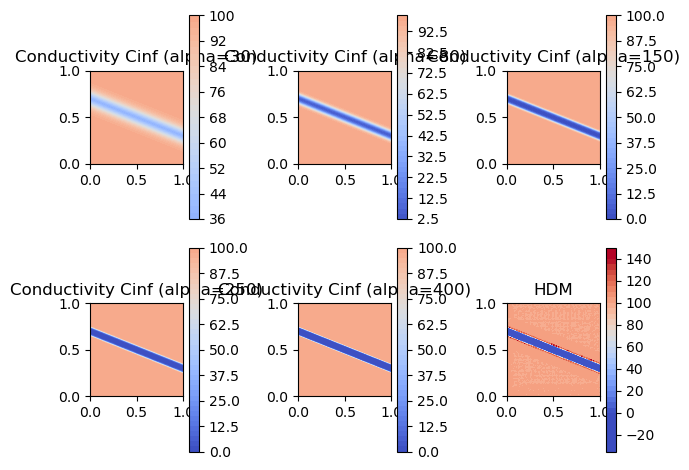

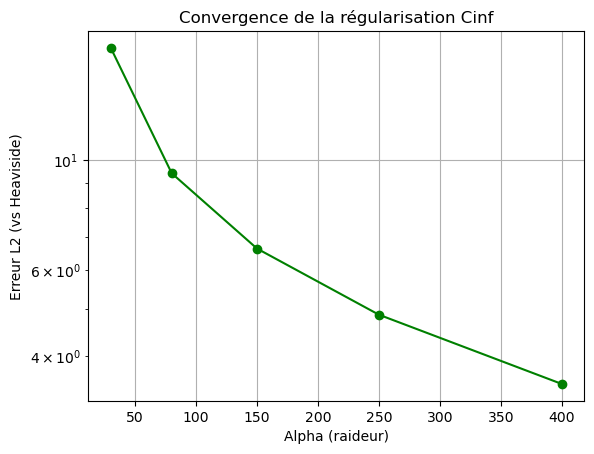

In [62]:
# Liste des alpha à tester
alpha_list = [30, 80, 150, 250, 400]
Erreur_sigmoide = np.zeros(len(alpha_list))

# 1. On fixe la cible (Heaviside/Limite) projetée une seule fois
K_lim_proj = project(get_conductivity(example_parameters), V)


for j, alpha_val in enumerate(alpha_list):
    # 2. Génération de l'expression symbolique Cinf
    K_expr = get_conductivity_Cinf2(example_parameters, alpha_val)
    
    # 3. Projection dans l'espace V pour le calcul et le plot
    # C'est cette étape qui transforme l'UFL en valeurs numériques
    K_proj = project(K_expr, V)
    
    # 4. Affichage
    plt.subplot(2, 3, j + 1)
    p = plot(K_proj, cmap="coolwarm", vmin=0.0, vmax=140.0)
    plt.colorbar(p)
    plt.title(f"Conductivity Cinf (alpha={alpha_val})")
    
    # 5. Calcul de l'erreur L2
    # On compare les deux versions projetées dans le même espace V
    Erreur_sigmoide[j] = errornorm(K_lim_proj, K_proj, norm_type='L2')
plt.subplot(2, 3, 6)
p = plot(K_lim_proj, cmap="coolwarm", vmin=0.0, vmax=140.0)
plt.colorbar(p)
plt.title("HDM")
    
plt.tight_layout()
plt.show()

# Petit bonus : tracer la courbe de convergence
plt.figure()
plt.semilogy(alpha_list, Erreur_sigmoide, marker='o', color='g')
plt.xlabel('Alpha (raideur)')
plt.ylabel('Erreur L2 (vs Heaviside)')
plt.title('Convergence de la régularisation Cinf')
plt.grid(True)
plt.show()


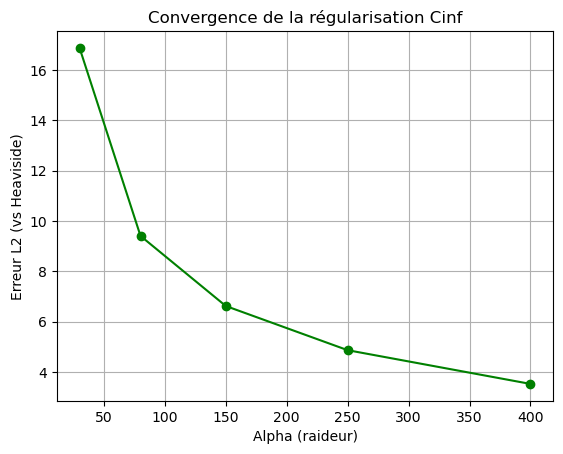

In [63]:
plt.figure()
plt.plot(alpha_list, Erreur_sigmoide, marker='o', color='g')
plt.xlabel('Alpha (raideur)')
plt.ylabel('Erreur L2 (vs Heaviside)')
plt.title('Convergence de la régularisation Cinf')
plt.grid(True)
plt.show()

In [64]:

def get_stiffness_and_load_Cinf2(parameters, alpha):
    K = get_conductivity_Cinf2(parameters, alpha)
    
    u = TrialFunction(V)
    v = TestFunction(V)

    a = inner(K*grad(u), grad(v))*dx
    L = Constant(0.0)*v*dx

    A = assemble(a)
    b = assemble(L)

    # Apply Dirichlet BCs to matrix and RHS vector
    b_mod = b.copy()
    A_uL = assemble(inner(K*grad(u_L), grad(v))*dx)
    b_mod.axpy(-1.0, A_uL)  # b_mod = b - A*u_L

    # Appliquer la BC homogène (u_0 = 0 sur bord)
    bc_zero.apply(A, b_mod)

    return A, b_mod

In [65]:
A_mu_Cinf2, b_mu_Cinf2 = get_stiffness_and_load_Cinf2(example_parameters, 400)
uh_HDM_sol_Cinf2 = Function(V)
solve(A_mu_Cinf2, uh_HDM_sol_Cinf2.vector(), b_mu_Cinf2)
uh_HDM_sol_Cinf2_vec = np.array(uh_HDM_sol_Cinf2.vector().get_local()) + u_L_vect


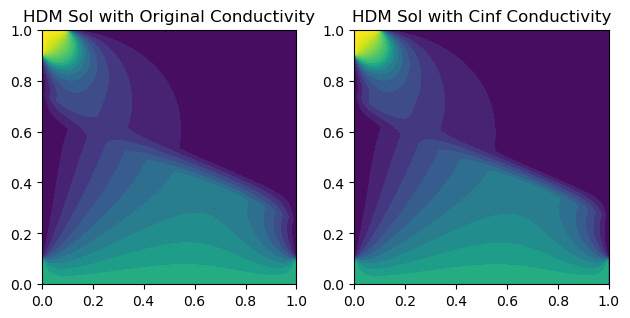

In [66]:
plt.subplot(1, 2, 1)
plot(uh_HDM_sol_comparaison, cmap="viridis", norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("HDM Sol with Original Conductivity")
plt.subplot(1, 2, 2)
plot(uh_HDM_sol_Cinf2, cmap="viridis", norm=colors.SymLogNorm(linthresh=1e0, vmin=0.0, vmax=4.0))
plt.title("HDM Sol with Cinf Conductivity")
plt.tight_layout()
plt.show()

In [67]:
print(errornorm(uh_HDM_sol_comparaison, uh_HDM_sol_Cinf2))

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
0.006985311344162002


Calcul des erreurs moyennes sur 10 paramètres de test.


Parcours des valeurs d'alpha:   0%|          | 0/5 [00:00<?, ?it/s]

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of

Parcours des valeurs d'alpha:  20%|██        | 1/5 [02:53<11:33, 173.30s/it]


Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-t

...

Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
Calling FFC just-in-time (JIT) compiler, this may take some time.
Calling FFC just-in-ti

Parcours des valeurs d'alpha:  80%|████████  | 4/5 [1:58:59<35:05, 2105.30s/it]  

*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warning: Degree of exact solution may be inadequate for accurate result in errornorm.
*** Warnin

Parcours des valeurs d'alpha: 100%|██████████| 5/5 [2:02:20<00:00, 1468.08s/it]



--- Résultats Moyens ---
Alpha =  30 | Err_K: 1.6864e+01 | Err_u: 5.9229e-02
Alpha =  80 | Err_K: 9.4711e+00 | Err_u: 2.7260e-02
Alpha = 150 | Err_K: 6.6936e+00 | Err_u: 2.0847e-02
Alpha = 250 | Err_K: 4.9639e+00 | Err_u: 1.5807e-02
Alpha = 400 | Err_K: 3.6610e+00 | Err_u: 1.0392e-02


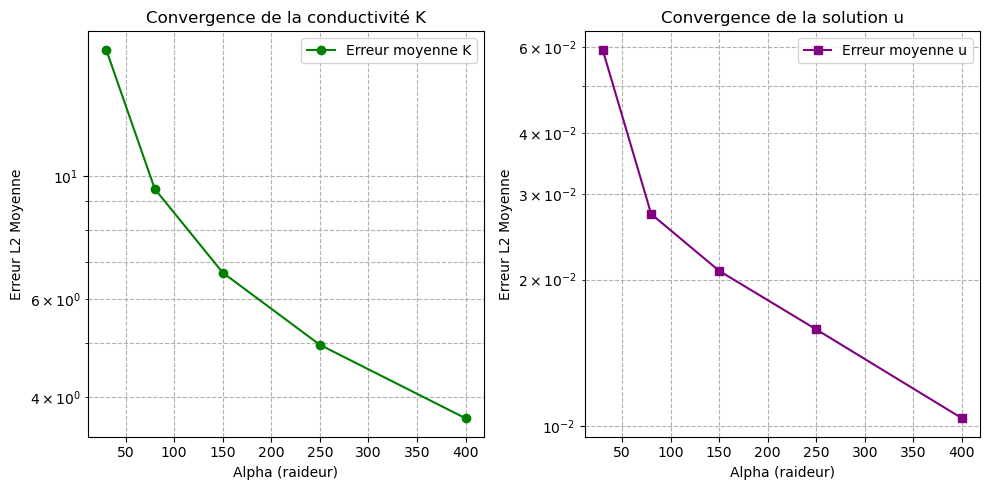

In [156]:
# Liste des alpha à tester
alpha_list = [30, 80, 150, 250, 400]

# Tableaux pour stocker les erreurs moyennes
Erreur_moyenne_K = np.zeros(len(alpha_list))
Erreur_moyenne_u = np.zeros(len(alpha_list))

N_test = len(parameters_test_non_lineaire_list)
print(f"Calcul des erreurs moyennes sur {N_test} paramètres de test.")

for j, alpha_val in enumerate(tqdm(alpha_list, desc="Parcours des valeurs d'alpha")):
    
    erreur_cumulee_K = 0.0
    erreur_cumulee_u = 0.0
    
    for i, params in enumerate(parameters_test_non_lineaire_list):
        
        # ==========================================
        # 1. Calcul de l'erreur sur la conductivité (K)
        # ==========================================
        # Référence (Heaviside propre)
        K_lim_func = project(get_conductivity(params), V)
        
        # Cinf (Sigmoïde)
        K_expr_cinf = get_conductivity_Cinf2(params, alpha_val)
        K_proj_cinf = project(K_expr_cinf, V)
        
        # Erreur (on peut utiliser errornorm car ce sont deux Functions)
        erreur_cumulee_K += errornorm(K_lim_func, K_proj_cinf, norm_type='L2')
        
        # ==========================================
        # 2. Calcul de l'erreur sur la solution (u)
        # ==========================================
        # Référence : la solution "Full Heaviside" que tu as précalculée !
        u_ref_heaviside = HF_sol_list[i]
        
        # On calcule le système avec la conductivité Cinf
        A_mu_cinf, b_mu_cinf = get_stiffness_and_load_Cinf2(params, alpha_val)
        u_cinf = Function(V)
        solve(A_mu_cinf, u_cinf.vector(), b_mu_cinf)
        
        # Erreur sur la solution (FEniCS gère la condition de Dirichlet dans u_cinf si tu utilises solve)
        erreur_cumulee_u += errornorm(u_ref_heaviside, u_cinf, norm_type='L2')
        
    # Moyenne pour l'alpha courant
    Erreur_moyenne_K[j] = erreur_cumulee_K / N_test
    Erreur_moyenne_u[j] = erreur_cumulee_u / N_test


# --- Affichage des résultats ---
print("\n--- Résultats Moyens ---")
for j, alpha_val in enumerate(alpha_list):
    print(f"Alpha = {alpha_val:3d} | Err_K: {Erreur_moyenne_K[j]:.4e} | Err_u: {Erreur_moyenne_u[j]:.4e}")

# Tracer les courbes de convergence
plt.figure(figsize=(10, 5))

# Sous-graphique 1 : Erreur sur K
plt.subplot(1, 2, 1)
plt.semilogy(alpha_list, Erreur_moyenne_K, marker='o', color='green', label="Erreur moyenne K")
plt.xlabel('Alpha (raideur)')
plt.ylabel('Erreur L2 Moyenne')
plt.title('Convergence de la conductivité K')
plt.grid(True, which="both", ls="--")
plt.legend()

# Sous-graphique 2 : Erreur sur u
plt.subplot(1, 2, 2)
plt.semilogy(alpha_list, Erreur_moyenne_u, marker='s', color='purple', label="Erreur moyenne u")
plt.xlabel('Alpha (raideur)')
plt.ylabel('Erreur L2 Moyenne')
plt.title('Convergence de la solution u')
plt.grid(True, which="both", ls="--")
plt.legend()

plt.tight_layout()
plt.show()

20

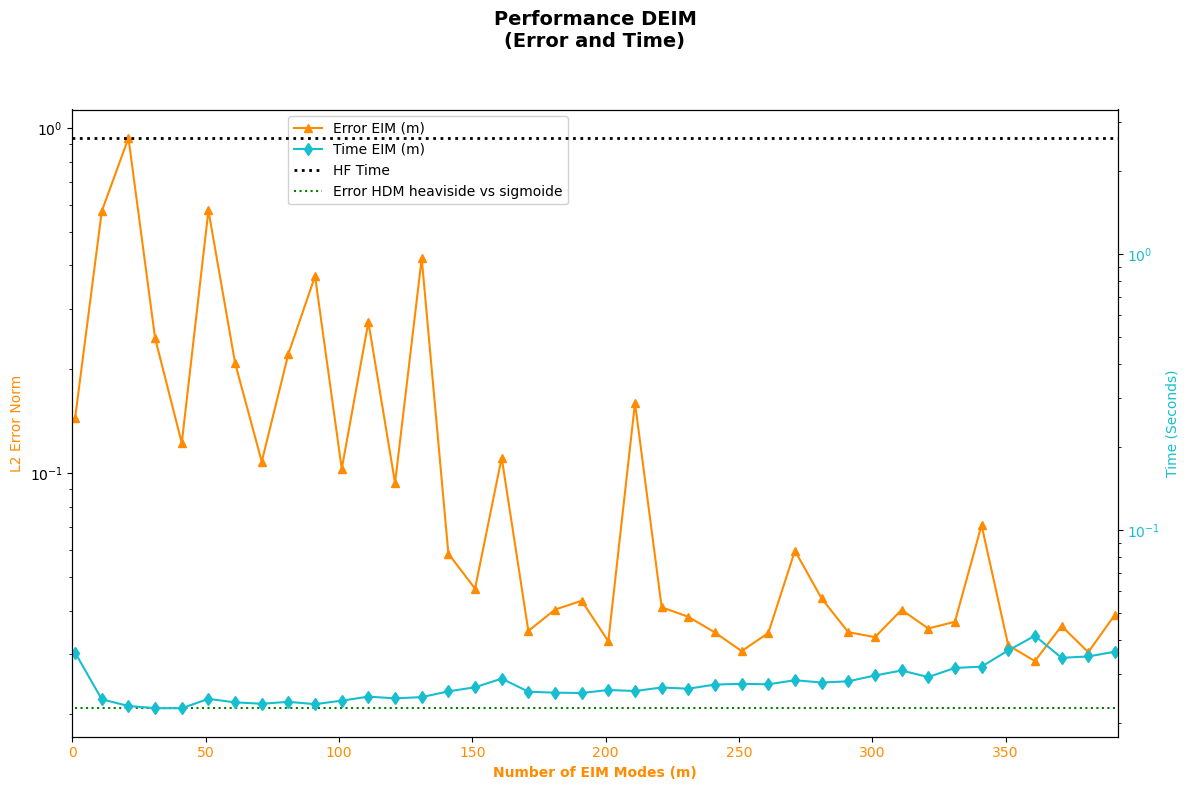

In [164]:
# Créer la figure
fig, ax1 = plt.subplots(figsize=(12, 8))

# =========================================================
# AXE Y GAUCHE : ERREURS (Norme A)
# =========================================================

# Erreur EIM (Bas / Gauche) -> Utilise l'axe Y gauche (ax1)
color_err_eim = 'darkorange'
ax1.set_xlabel('Number of EIM Modes (m)', color=color_err_eim, fontweight='bold')
l3, = ax1.semilogy(M_EIM, error_L2_EIM_Cinf_heaviside, marker='^', 
               color=color_err_eim, label='Error EIM (m)')
ax1.tick_params(axis='x', labelcolor=color_err_eim)
ax1.set_ylabel('L2 Error Norm', color=color_err_eim)

# Ajout de la valeur théorique optimale en pointillés
l_opt = ax1.semilogy(M_EIM, [Erreur_moyenne_u[2] for r_EIM in M_EIM], 
                 marker='', linestyle=':', color='green', label='Error HDM heaviside vs sigmoide')

# =========================================================
# AXE Y DROIT : TEMPS (Secondes)
# =========================================================

ax2 = ax1.twinx()  # Partage l'axe X mais crée un nouvel axe Y droit
color_time_eim = 'tab:cyan'
l4, = ax2.semilogy(M_EIM, time_EIM_Cinf, marker='d', 
                   color=color_time_eim, label='Time EIM (m)')
ax2.tick_params(axis='y', labelcolor=color_time_eim)
ax2.set_ylabel('Time (Seconds)', color=color_time_eim)

# Ligne de référence HF
l_hf = ax2.axhline(y=HF_compution_time, color='black', linestyle=':', linewidth=2, label='HF Time')

# =========================================================
# AJUSTEMENTS ESTHÉTIQUES ET LÉGENDE
# =========================================================



# IMPORTANT : Synchroniser les limites des axes X du haut (m) pour superposer les points
ax1.set_xlim(min(M_EIM)-1, max(M_EIM)+1)
ax2.set_xlim(min(M_EIM)-1, max(M_EIM)+1)

# Regrouper toutes les lignes dans une seule et belle légende
lines = [l3, l4, l_hf, l_opt[0]]
labels = [l.get_label() for l in lines]
# On place la légende à un endroit qui gêne le moins (à adapter selon tes courbes)
ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(0.2, 1), framealpha=0.9)

# Titre général (pad éloigne le titre de l'axe supérieur)
plt.title('Performance DEIM\n(Error and Time)', pad=45, fontsize=14, fontweight='bold')

fig.tight_layout()
plt.show()